# Thực hành Bài 04 — Lặp chính sách và lặp giá trị trên CartPole rời rạc hóa

Học tăng cường — Học kỳ 1, năm học 2026–2027

Bài 04 giải quá trình quyết định Markov (MDP) hữu hạn bằng quy hoạch động khi mô hình $p(s',r\mid s,a)$ đã biết. Cuối bài, CartPole được chia thành $3\cdot3\cdot6\cdot6=324$ ô để đưa về bảng; bài giảng cũng nêu rằng rời rạc hóa chưa cung cấp mô hình chuyển, và cần mô phỏng để ước lượng mô hình đó (Tạ Việt Cường, *Bài 04: Giải MDP*, tr. 35–37). Notebook này thực hiện đầy đủ chuỗi bước đó trên môi trường `CartPole-v1` của thư viện Gymnasium.

**Mục tiêu học tập.** Sau buổi thực hành, sinh viên có thể:

1. dựng môi trường CartPole, đọc không gian trạng thái, hành động, phần thưởng và phân biệt kết thúc với cắt ngắn theo thời gian;
2. đánh giá một chính sách qua nhiều lượt với tập hạt giống cố định, báo cáo trung bình kèm sai số chuẩn và so sánh hai chính sách theo cặp;
3. rời rạc hóa trạng thái liên tục, ước lượng mô hình bảng $\hat p(s'\mid s,a)$ bằng mô phỏng và kiểm tra mô hình đó;
4. cài đặt đánh giá chính sách, lặp chính sách và lặp giá trị đúng quy trình của Bài 04, kể cả quy tắc giữ hòa, ngưỡng phần dư và nhãn dừng;
5. đánh giá chính sách thu được trong môi trường liên tục và tách sai số lặp khỏi sai số do rời rạc hóa và ước lượng mô hình.

**Tiên quyết.** Bài 03 (MDP, phương trình Bellman kỳ vọng, tổng thưởng chiết khấu) và Bài 04 (toán tử $T_\pi$, $T_*$, lặp chính sách, lặp giá trị, phần dư Bellman). Python cơ bản và NumPy.

**Cách dùng.** Chạy các ô theo thứ tự từ trên xuống. Ô cài đặt ở phần 1 tự cài các gói cần thiết, nên notebook chạy được trên Jupyter cục bộ hoặc Google Colab mà không cần tệp nào khác. Mọi phép ngẫu nhiên dùng hạt giống (seed) cố định, nên chạy lại với cùng phiên bản các gói cho cùng số liệu; phiên bản khác có thể cho số liệu lệch nhẹ. Các ô **Câu hỏi:** có lời giải thu gọn; nên tự trả lời trước khi mở. Trên máy dùng để soạn notebook, toàn bộ các ô chạy dưới một phút trên CPU, chưa kể thời gian cài gói.

**Ký hiệu** (thống nhất với ghi chú Bài 04):

| Ký hiệu, thuật ngữ | Ý nghĩa trong notebook |
| --- | --- |
| lượt | một episode: từ `reset` tới khi kết thúc hoặc bị cắt ngắn |
| lượt quét | một lần áp dụng toán tử Bellman lên mọi ô (ghi chú Bài 04 gọi tắt là lượt) |
| $\mathcal S$, $n=\lvert\mathcal S\rvert$ | tập ô chưa kết thúc sau rời rạc hóa, $n=324$ |
| $s_{\mathrm{term}}$, $\mathcal S^+$ | trạng thái kết thúc (chỉ số $n=324$ trong mảng), $\mathcal S^+=\mathcal S\cup\{s_{\mathrm{term}}\}$; giá trị tại $s_{\mathrm{term}}$ luôn bằng $0$ |
| $p(s',r\mid s,a)$ | mô hình đúng của MDP trong Bài 04; với CartPole rời rạc hóa, mô hình này không có sẵn |
| $\hat p(s'\mid s,a)$, $\hat r(s,a)$ | mô hình bảng ước lượng bằng mô phỏng: xác suất sang ô $s'$ và phần thưởng kỳ vọng; mọi thuật toán ở phần 6–7 chạy trên $(\hat p,\hat r)$ |
| $M$ | số trạng thái liên tục được lấy mẫu trong mỗi ô khi ước lượng $\hat p$ |
| $\gamma$ | hệ số chiết khấu, dùng $\gamma=0{,}99$ |
| $Q_V(s,a)$ | giá trị nhìn trước một bước từ bảng $V$: $\hat r(s,a)+\gamma\sum_{s'}\hat p(s'\mid s,a)V(s')$ |
| $T_\pi$, $T_*$ | toán tử Bellman của chính sách $\pi$ và toán tử Bellman tối ưu |
| $\Delta_\pi(V)$, $\Delta_*(V)$ | phần dư Bellman $\lVert T_\pi V-V\rVert_\infty$ và $\lVert T_*V-V\rVert_\infty$ |
| $\pi_V$ | chính sách tham lam trích từ bảng $V$: $\pi_V(s)\in\arg\max_a Q_V(s,a)$ |
| quy tắc giữ hòa | khi hành động cũ thuộc $\arg\max$ thì giữ hành động cũ (trên trang chiếu: quy tắc phá hòa) |
| $\eta$, $\varepsilon$ | ngưỡng phần dư và sai số giá trị yêu cầu, $\eta=(1-\gamma)\varepsilon$ |
| $K$, $I_{\max}$ | ngân sách số lần nhận bảng mới; ngân sách số vòng đánh giá–cải thiện |

## 1. Cài đặt và chuẩn bị

Ô dưới cài Gymnasium, NumPy và Matplotlib. Nếu Gymnasium có sẵn cũ hơn bản 1.0 (có thể gặp trên Colab), `pip` nâng cấp lên bản mới; NumPy và Matplotlib đã có thì giữ nguyên bản sẵn có. Nếu môi trường cục bộ đã cài đủ, có thể bỏ qua ô này.

`pip` có thể in dòng *Note: you may need to restart the kernel to use updated packages*. Khi ô cài đặt được chạy trước mọi lệnh `import`, không cần khởi động lại. Nếu trước đó đã `import` một bản cũ của gói vừa được nâng cấp, cần khởi động lại kernel rồi chạy lại notebook từ đầu.

In [1]:
%pip install -q "gymnasium>=1.0" numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import time

import numpy as np
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt

print("gymnasium", gym.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

ENV_ID = "CartPole-v1"
SEED = 2026          # hạt giống cho thu thập dữ liệu và ước lượng mô hình
EVAL_SEED = 10_000   # tập hạt giống riêng cho đánh giá, không trùng dữ liệu xây mô hình
N_ACTIONS = 2
np.set_printoptions(precision=4, suppress=True)


def make_env(**kwargs):
    # Môi trường đầy đủ: có giới hạn 500 bước và các lớp kiểm tra của Gymnasium
    return gym.make(ENV_ID, **kwargs)


T0 = time.perf_counter()  # đo tổng thời gian chạy notebook

gymnasium 1.3.0 | numpy 2.5.3 | matplotlib 3.11.2


## 2. Môi trường CartPole

**Bài toán.** Một xe chạy trên ray nằm ngang, trên xe gắn một cột quay tự do. Ở mỗi bước, tác tử đẩy xe sang trái hoặc sang phải với lực cố định; mục tiêu là giữ cột đứng lâu nhất có thể.

- Trạng thái (cũng là quan sát) $s=(x,\dot x,\theta,\dot\theta)$: vị trí xe, vận tốc xe, góc của cột so với phương thẳng đứng, vận tốc góc.
- Hành động $a\in\{0,1\}$: $0$ đẩy xe sang trái, $1$ đẩy xe sang phải.
- Phần thưởng: $+1$ cho mỗi bước, kể cả bước dẫn tới kết thúc.
- **Kết thúc** (`terminated`): $\lvert\theta\rvert$ vượt ngưỡng góc hoặc $\lvert x\rvert$ vượt ngưỡng vị trí. Đây là trạng thái kết thúc $s_{\mathrm{term}}$ của MDP.
- **Cắt ngắn** (`truncated`): lượt đạt giới hạn số bước. Giới hạn này do cấu hình đăng ký môi trường (`max_episode_steps`) quy định và không xuất phát từ động lực học, nên mô hình MDP ở các phần sau không chứa nó.

Các ngưỡng được đọc từ chính đối tượng môi trường thay vì ghi số cứng.

In [3]:
env = make_env()
core = env.unwrapped  # đối tượng động lực học bên dưới các lớp bao

print("Không gian quan sát :", env.observation_space)
print("Không gian hành động:", env.action_space)
print(f"Ngưỡng vị trí       : |x| > {core.x_threshold}")
print(f"Ngưỡng góc          : |theta| > {core.theta_threshold_radians:.4f} rad = {math.degrees(core.theta_threshold_radians):.1f} độ")
print(f"Bước thời gian tau  : {core.tau} giây")
print(f"Giới hạn số bước    : {env.spec.max_episode_steps}  (max_episode_steps)")

Không gian quan sát : Box([-4.8       -inf -0.4189    -inf], [4.8       inf 0.4189    inf], (4,), float32)
Không gian hành động: Discrete(2)
Ngưỡng vị trí       : |x| > 2.4
Ngưỡng góc          : |theta| > 0.2094 rad = 12.0 độ
Bước thời gian tau  : 0.02 giây
Giới hạn số bước    : 500  (max_episode_steps)


Biên của `observation_space` (ví dụ $4{,}8$ cho $x$) lớn gấp đôi ngưỡng kết thúc; hai vận tốc không bị chặn. Do đó biên rời rạc hóa không thể lấy trực tiếp từ `observation_space` mà phải dựa vào ngưỡng kết thúc và dữ liệu quan sát (phần 4).

Lượt dưới dùng chính sách luôn đẩy phải. Khi xe liên tục được đẩy sang phải, $\theta$ giảm dần cho tới khi vượt ngưỡng góc về phía âm. Phần thưởng ở bước cuối vẫn là $+1$, nên tổng thưởng của một lượt bằng số bước của lượt đó.

In [4]:
obs, info = env.reset(seed=SEED)
print(" t        x    x_dot    theta  theta_dot  a    r  terminated  truncated")
print(f"{0:2d} {obs[0]:8.4f} {obs[1]:8.4f} {obs[2]:8.4f} {obs[3]:10.4f}")
t, total = 0, 0.0
while True:
    a = 1  # luôn đẩy phải
    obs, r, terminated, truncated, info = env.step(a)
    t += 1
    total += r
    print(f"{t:2d} {obs[0]:8.4f} {obs[1]:8.4f} {obs[2]:8.4f} {obs[3]:10.4f}  {a} {r:4.1f}  {terminated!s:>10}  {truncated!s:>9}")
    if terminated or truncated:
        break
print(f"Tổng thưởng = {total:.0f} = số bước = {t}")

 t        x    x_dot    theta  theta_dot  a    r  terminated  truncated
 0  -0.0321   0.0140  -0.0033    -0.0129
 1  -0.0318   0.2092  -0.0035    -0.3067  1  1.0       False      False
 2  -0.0276   0.4043  -0.0097    -0.6005  1  1.0       False      False
 3  -0.0196   0.5996  -0.0217    -0.8962  1  1.0       False      False
 4  -0.0076   0.7950  -0.0396    -1.1956  1  1.0       False      False
 5   0.0083   0.9906  -0.0635    -1.5004  1  1.0       False      False
 6   0.0281   1.1864  -0.0935    -1.8122  1  1.0       False      False
 7   0.0519   1.3825  -0.1298    -2.1324  1  1.0       False      False
 8   0.0795   1.5786  -0.1724    -2.4622  1  1.0       False      False
 9   0.1111   1.7747  -0.2217    -2.8025  1  1.0        True      False
Tổng thưởng = 9 = số bước = 9


**Câu hỏi:** Với phần thưởng $+1$ mỗi bước và hệ số chiết khấu $\gamma<1$, viết tổng thưởng chiết khấu $G_0$ của một lượt dài $T$ bước theo $T$ và $\gamma$. Giá trị lớn nhất của $G_0$ khi lượt không bao giờ kết thúc là bao nhiêu?

<details><summary>Lời giải</summary>

$G_0=\sum_{t=0}^{T-1}\gamma^t=\dfrac{1-\gamma^T}{1-\gamma}$. Khi $T\to\infty$, $G_0\to 1/(1-\gamma)$; với $\gamma=0{,}99$ cận này bằng $100$. Vì mọi phần thưởng bằng nhau, giá trị của một trạng thái trong bài này là kỳ vọng của $(1-\gamma^T)/(1-\gamma)$, tức một hàm tăng của thời gian giữ cột. Phần 8 dùng lại công thức này để đổi số bước của một lượt thành tổng thưởng chiết khấu.

</details>

## 3. Đánh giá một chính sách qua nhiều lượt

**Vấn đề.** Trạng thái đầu của CartPole được rút ngẫu nhiên. Cùng một chính sách cho độ dài lượt khác nhau giữa các lần chạy, nên một lượt duy nhất không đủ để so sánh hai chính sách. Mã nguồn `CartPoleEnv.reset` rút mỗi thành phần đều trong $[-0{,}05;\,0{,}05]$; ô dưới kiểm tra điều đó trên $100$ hạt giống đánh giá.

In [5]:
starts = np.array([env.reset(seed=EVAL_SEED + i)[0] for i in range(100)])  # (100, 4)
print("nhỏ nhất theo từng biến:", starts.min(axis=0))
print("lớn nhất theo từng biến:", starts.max(axis=0))

nhỏ nhất theo từng biến: [-0.0494 -0.0485 -0.0498 -0.0492]
lớn nhất theo từng biến: [0.0475 0.0492 0.0498 0.0496]


**Thiết lập đánh giá.** Chạy $N$ lượt; lượt thứ $i$ dùng hạt giống `seed + i` cho cả trạng thái đầu và bộ sinh số ngẫu nhiên của chính sách. Gọi $G^{(i)}$ là tổng thưởng (không chiết khấu) của lượt $i$, bằng số bước của lượt. Các đại lượng báo cáo:

$$\bar G=\frac1N\sum_{i=1}^N G^{(i)},\qquad \mathrm{sd}=\sqrt{\frac{1}{N-1}\sum_{i=1}^N\big(G^{(i)}-\bar G\big)^2},\qquad \mathrm{SE}=\frac{\mathrm{sd}}{\sqrt N},$$

tức trung bình, độ lệch chuẩn (sd) và sai số chuẩn (SE) của trung bình. Theo xấp xỉ chuẩn, $\bar G\pm1{,}96\,\mathrm{SE}$ là khoảng tin cậy xấp xỉ $95\%$ cho tổng thưởng kỳ vọng.

**So sánh theo cặp.** Hai chính sách A và B được chạy trên cùng tập hạt giống, nên lượt $i$ của cả hai bắt đầu từ cùng trạng thái. Hiệu $d_i=G^{(i)}_A-G^{(i)}_B$ loại phần biến thiên do trạng thái đầu, và $\bar d\pm1{,}96\,\mathrm{SE}(d)$ là khoảng tin cậy xấp xỉ $95\%$ cho hiệu tổng thưởng kỳ vọng.

Ánh xạ sang mã: `res["returns"]` là mảng $(G^{(1)},\dots,G^{(N)})$ cỡ $(N,)$; `res["seeds"]` lưu hạt giống của từng lượt để kiểm tra hai kết quả có ghép cặp được không. Một chính sách là hàm `policy(obs, rng) -> action`; chính sách tất định bỏ qua `rng`.

In [6]:
def run_episode(env, policy, seed):
    # Một lượt; trả về (G = số bước, có bị cắt ngắn không, trạng thái đầu)
    rng = np.random.default_rng(seed)  # bộ sinh số của chính sách, cùng hạt giống với trạng thái đầu
    obs, _ = env.reset(seed=seed)
    start = obs.copy()
    steps = 0
    while True:
        obs, r, terminated, truncated, _ = env.step(policy(obs, rng))
        steps += 1  # r = +1 ở mọi bước nên G bằng số bước
        if terminated or truncated:
            return steps, truncated, start


def evaluate(policy, n_episodes=100, seed=EVAL_SEED, env_kwargs=None):
    env = make_env(**(env_kwargs or {}))  # env_kwargs: ví dụ max_episode_steps khác
    seeds = seed + np.arange(n_episodes)
    runs = [run_episode(env, policy, int(sd)) for sd in seeds]
    env.close()
    return {
        "seeds": seeds,
        "returns": np.array([r[0] for r in runs], dtype=float),  # G^(i), cỡ (N,)
        "truncated": np.array([r[1] for r in runs]),
        "starts": np.array([r[2] for r in runs]),                # cỡ (N, 4)
    }


def summarize(name, res):
    g = res["returns"]
    se = g.std(ddof=1) / math.sqrt(len(g))  # SE = sd / sqrt(N), sd dùng mẫu số N - 1
    print(f"{name:<22} N={len(g):3d}  trung bình={g.mean():6.1f}  sd={g.std(ddof=1):6.1f}  "
          f"SE={se:5.1f}  min={g.min():4.0f}  max={g.max():4.0f}  cắt ngắn={res['truncated'].mean():5.1%}")


def paired_difference(res_a, res_b):
    # d_i = G_A^(i) - G_B^(i); chỉ hợp lệ khi hai kết quả dùng cùng dãy hạt giống
    assert np.array_equal(res_a["seeds"], res_b["seeds"])
    d = res_a["returns"] - res_b["returns"]
    half = 1.96 * d.std(ddof=1) / math.sqrt(len(d))  # 1,96 * SE(d)
    return d.mean(), half


def random_policy(obs, rng):
    return int(rng.integers(N_ACTIONS))


def angle_policy(obs, rng):
    # Đẩy xe về phía cột đang nghiêng: theta >= 0 thì đẩy phải
    return int(obs[2] >= 0)

Hai chính sách tham chiếu: chọn ngẫu nhiên đều và luật theo dấu góc. Luật theo dấu góc chỉ dùng $\theta$, bỏ qua $\dot\theta$, $x$ và $\dot x$.

ngẫu nhiên             N=100  trung bình=  22.5  sd=  11.5  SE=  1.1  min=   9  max=  61  cắt ngắn= 0.0%
theo dấu góc           N=100  trung bình=  43.6  sd=   9.6  SE=  1.0  min=  25  max=  68  cắt ngắn= 0.0%

Hiệu theo cặp (theo dấu góc - ngẫu nhiên): 21.1 ± 2.9


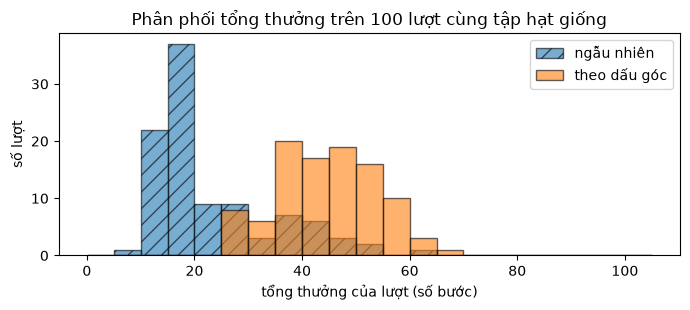

In [7]:
N_EVAL = 100  # số lượt đánh giá; SE giảm theo 1/sqrt(N_EVAL)
res_random = evaluate(random_policy, N_EVAL)  # cùng tập hạt giống EVAL_SEED + i cho mọi chính sách
res_angle = evaluate(angle_policy, N_EVAL)
summarize("ngẫu nhiên", res_random)
summarize("theo dấu góc", res_angle)
d, half = paired_difference(res_angle, res_random)
print(f"\nHiệu theo cặp (theo dấu góc - ngẫu nhiên): {d:.1f} ± {half:.1f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.arange(0, 110, 5)
ax.hist(res_random["returns"], bins=bins, alpha=0.6, label="ngẫu nhiên", hatch="//", edgecolor="k")
ax.hist(res_angle["returns"], bins=bins, alpha=0.6, label="theo dấu góc", edgecolor="k")
ax.set_xlabel("tổng thưởng của lượt (số bước)")
ax.set_ylabel("số lượt")
ax.set_title(f"Phân phối tổng thưởng trên {N_EVAL} lượt cùng tập hạt giống")
ax.legend()
plt.tight_layout()
plt.show()

**Câu hỏi:** (a) Với $N=100$ lượt, khoảng tin cậy xấp xỉ $95\%$ của trung bình có độ rộng bao nhiêu theo SE in ở trên? (b) Nếu chính sách A được đánh giá trên hạt giống $0$–$99$ và chính sách B trên hạt giống $100$–$199$, khác biệt trung bình còn chứa những nguồn biến thiên nào, và hàm `paired_difference` còn dùng được không?

<details><summary>Lời giải</summary>

(a) Khoảng là $\bar G\pm1{,}96\,\mathrm{SE}$, độ rộng $3{,}92\,\mathrm{SE}$; thay SE in ở trên cho từng chính sách. (b) Ngoài khác biệt giữa hai chính sách, hiệu trung bình còn chứa khác biệt giữa hai tập trạng thái đầu. Khi đó các lượt không ghép cặp được: `paired_difference` dừng ở lệnh `assert`, và phải dùng sai số chuẩn của hiệu hai trung bình độc lập $\sqrt{\mathrm{SE}_A^2+\mathrm{SE}_B^2}$. Với cùng tập hạt giống, lượt $i$ của hai chính sách bắt đầu từ cùng trạng thái, và nếu độ dài lượt của hai chính sách tương quan dương theo trạng thái đầu thì $\mathrm{SE}(d)$ nhỏ hơn sai số chuẩn của hiệu hai trung bình độc lập. Với chính sách ngẫu nhiên, hạt giống chung còn cố định dãy số ngẫu nhiên của chính sách.

</details>

### 3.1. Trực quan hóa một lượt của hai chính sách tham chiếu

Histogram cho biết phân phối độ dài lượt nhưng không cho biết lượt kết thúc vì sao. Mục này ghi lại toàn bộ một lượt của hai chính sách tham chiếu và vẽ lại chuyển động của xe và cột.

**Hình học CartPole.** Trạng thái $(x,\dot x,\theta,\dot\theta)$ được đọc như sau: $x$ là vị trí tâm xe trên ray, $\theta$ là góc của cột so với phương thẳng đứng, $\theta>0$ khi cột nghiêng sang phải. Mỗi bước kéo dài $\tau=0{,}02$ giây. Thuộc tính `length` của `env.unwrapped` là nửa chiều dài cột, nên cột được vẽ dài `2 * length`; kích thước xe trong hình chỉ để minh họa. Lượt kết thúc khi $\lvert\theta\rvert$ vượt ngưỡng góc hoặc $\lvert x\rvert$ vượt ngưỡng vị trí, và bị cắt ngắn ở giới hạn số bước.

**Các hàm.** Mọi hàm nhận tham số rõ ràng và không đọc biến toàn cục tạo về sau; phần 8 dùng lại chúng cho bốn chính sách.

- `cartpole_geometry(env)` gom các hằng số đọc từ môi trường vào một từ điển `geom`: hai ngưỡng kết thúc, nửa chiều dài cột, $\tau$ và giới hạn số bước.
- `record_episode(env, policy, seed, cell_fn=None)` chạy giống `run_episode` nhưng lưu mọi bước: `states` là $(s_0,\dots,s_T)$, cỡ $(T+1,4)$; `actions` là $(a_0,\dots,a_{T-1})$, cỡ $(T,)$; `rewards` cỡ $(T,)$; hai cờ của bước cuối; và khi truyền hàm `cell_fn`, `cells` là chỉ số ô của từng trạng thái, cỡ $(T+1,)$.
- `end_reason(ep, geom)` đọc lý do kết thúc từ trạng thái cuối $s_T$ và các ngưỡng.

Vì cùng quy ước hạt giống với `run_episode`, lượt ghi lại trùng với lượt tương ứng trong phép đánh giá; phép kiểm `assert` so độ dài hai lượt. Hạt giống minh họa là lượt mà độ dài của luật theo dấu góc gần trung vị nhất, để lượt được chọn không phải lượt tốt nhất hay tệ nhất; phần 8 dùng lại cùng hạt giống.

In [8]:
def cartpole_geometry(env):
    core_env = env.unwrapped
    return {"x_threshold": core_env.x_threshold,
            "theta_threshold": core_env.theta_threshold_radians,
            "half_length": core_env.length,          # nửa chiều dài cột
            "tau": core_env.tau,
            "max_steps": env.spec.max_episode_steps}


def record_episode(env, policy, seed, cell_fn=None):
    rng = np.random.default_rng(seed)               # cùng quy ước hạt giống với run_episode
    obs, _ = env.reset(seed=seed)
    states, actions, rewards = [obs.copy()], [], []
    while True:
        a = policy(obs, rng)
        obs, r, terminated, truncated, _ = env.step(a)
        states.append(obs.copy())
        actions.append(a)
        rewards.append(r)
        if terminated or truncated:
            break
    ep = {"states": np.array(states),                 # (T+1, 4)
          "actions": np.array(actions),               # (T,)
          "rewards": np.array(rewards),               # (T,)
          "terminated": terminated, "truncated": truncated}
    if cell_fn is not None:
        ep["cells"] = np.array([cell_fn(s) for s in states])  # (T+1,)
    return ep


def end_reason(ep, geom):
    x_T, theta_T = ep["states"][-1, 0], ep["states"][-1, 2]  # trạng thái cuối s_T
    if ep["truncated"]:
        return f"cắt ngắn ở {geom['max_steps']} bước"
    if abs(theta_T) > geom["theta_threshold"]:
        return f"|θ| > {math.degrees(geom['theta_threshold']):.0f} độ"
    if abs(x_T) > geom["x_threshold"]:
        return f"|x| > {geom['x_threshold']}"
    return "không rõ"


def describe_episodes(episodes, geom):
    for name, ep in episodes.items():
        T = len(ep["actions"])
        print(f"{name:<15} T = {T:3d} bước ({T * geom['tau']:5.2f} giây), kết thúc do {end_reason(ep, geom)}, "
              f"|x| lớn nhất = {np.abs(ep['states'][:, 0]).max():.3f}, "
              f"|theta| lớn nhất trước bước cuối = {np.degrees(np.abs(ep['states'][:-1, 2])).max():.1f} độ")


geom = cartpole_geometry(env)
g_angle = res_angle["returns"]
i_viz = int(np.argmin(np.abs(g_angle - np.median(g_angle))))  # lượt có độ dài gần trung vị
VIZ_SEED = int(res_angle["seeds"][i_viz])

viz_env = make_env()
episodes_ref = {"ngẫu nhiên": record_episode(viz_env, random_policy, VIZ_SEED),
                "theo dấu góc": record_episode(viz_env, angle_policy, VIZ_SEED)}
viz_env.close()
assert len(episodes_ref["ngẫu nhiên"]["actions"]) == res_random["returns"][i_viz]
assert len(episodes_ref["theo dấu góc"]["actions"]) == res_angle["returns"][i_viz]
print(f"Hạt giống minh họa: {VIZ_SEED} (lượt thứ {i_viz} của phép đánh giá); trạng thái đầu {episodes_ref['ngẫu nhiên']['states'][0]}")
describe_episodes(episodes_ref, geom)

Hạt giống minh họa: 10004 (lượt thứ 4 của phép đánh giá); trạng thái đầu [ 0.0339 -0.0198 -0.004  -0.0137]
ngẫu nhiên      T =  12 bước ( 0.24 giây), kết thúc do |θ| > 12 độ, |x| lớn nhất = 0.127, |theta| lớn nhất trước bước cuối = 10.9 độ
theo dấu góc    T =  42 bước ( 0.84 giây), kết thúc do |θ| > 12 độ, |x| lớn nhất = 0.219, |theta| lớn nhất trước bước cuối = 11.6 độ


**Đồ thị theo thời gian.** Hàm `plot_trajectories` vẽ $\theta(t)$ (đổi sang độ) và $x(t)$ của các lượt trên cùng trục thời gian, kèm đường chấm ngang tại ngưỡng kết thúc $\pm12^\circ$ và $\pm2{,}4$. Các chính sách được phân biệt bằng kiểu nét và ký hiệu điểm trong `STYLES`, nên hình đọc được cả khi không phân biệt màu.

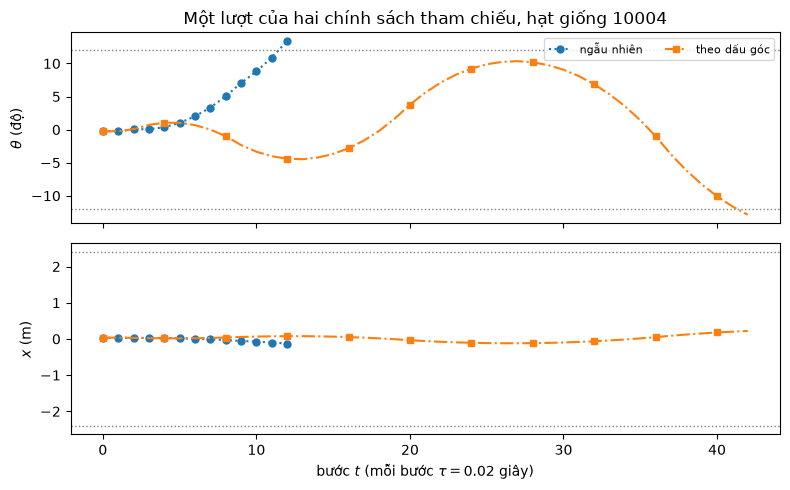

Cực trị của theta (độ) theo thời gian, luật theo dấu góc: [-0.2  1.  -4.5 10.3]
Trị tuyệt đối các cực trị tăng dần: True


In [9]:
STYLES = {  # kiểu nét và ký hiệu điểm cho từng chính sách, dùng lại ở phần 8
    "ngẫu nhiên": dict(ls=":", marker="o"),
    "theo dấu góc": dict(ls="-.", marker="s"),
    "lặp chính sách": dict(ls="-", marker="^"),
    "lặp giá trị": dict(ls="--", marker="x"),
}


def plot_trajectories(episodes, geom, styles, title):
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    for name, ep in episodes.items():
        t = np.arange(len(ep["states"]))                     # bước t = 0..T
        every = max(1, len(t) // 10)                          # ký hiệu điểm thưa để không che đường
        axes[0].plot(t, np.degrees(ep["states"][:, 2]), label=name, markevery=every, ms=5, **styles[name])
        axes[1].plot(t, ep["states"][:, 0], label=name, markevery=every, ms=5, **styles[name])
    for ax, thr in [(axes[0], math.degrees(geom["theta_threshold"])), (axes[1], geom["x_threshold"])]:
        ax.axhline(thr, color="gray", ls=":", lw=1)           # ngưỡng kết thúc
        ax.axhline(-thr, color="gray", ls=":", lw=1)
    axes[0].set_ylabel(r"$\theta$ (độ)")
    axes[1].set_ylabel(r"$x$ (m)")
    axes[1].set_xlabel(rf"bước $t$ (mỗi bước $\tau={geom['tau']}$ giây)")
    axes[0].set_title(title)
    axes[0].legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


plot_trajectories(episodes_ref, geom, STYLES, f"Một lượt của hai chính sách tham chiếu, hạt giống {VIZ_SEED}")

# Các cực trị địa phương của theta trong lượt của luật theo dấu góc
th = np.degrees(episodes_ref["theo dấu góc"]["states"][:-1, 2])
peaks = [th[i] for i in range(1, len(th) - 1) if (th[i] - th[i - 1]) * (th[i + 1] - th[i]) < 0]
print("Cực trị của theta (độ) theo thời gian, luật theo dấu góc:", np.round(peaks, 1))
print("Trị tuyệt đối các cực trị tăng dần:", bool(np.all(np.diff(np.abs(peaks)) > 0)))

**Hoạt hình.** Trình phát dưới vẽ trên phần tử `<canvas>` của trình duyệt từ mảng trạng thái đã ghi; dữ liệu nhúng cỡ vài chục kilobyte. Mỗi lượt có một ô rộng $400$ px: ray nằm ngang, hai vạch chấm tại $x=\pm2{,}4$, xe là hình chữ nhật tâm tại $x$, cột gắn ở mặt trên của xe nghiêng góc $\theta$ ($\theta>0$: nghiêng phải) và dài `2 * length`, mũi tên chỉ hướng lực của hành động tại bước đó. Các ô chạy cùng bước thời gian; ô của lượt đã dừng giữ khung cuối và ghi bước dừng cùng lý do.

Nút **Phát/Dừng** chạy hoặc dừng hoạt hình, thanh trượt tua tới một bước bất kỳ, và ô chọn tốc độ đặt tốc độ phát so với thời gian thực: ở tốc độ $1\times$, mỗi bước $\tau=0{,}02$ giây được phát trong $20$ mili giây.

Hàm Python `cartpole_player` chỉ đóng gói dữ liệu (tọa độ $x$, góc $\theta$, hành động, độ dài và lý do kết thúc của từng lượt, cùng các hằng số hình học) thành JSON rồi chèn vào một mẫu HTML có đoạn JavaScript vẽ hình; mọi phép vẽ do trình duyệt thực hiện. Trình phát cần JavaScript và chạy được trong các giao diện cho phép JavaScript trong output, như Jupyter, JupyterLab, VS Code hay Colab (khi soạn notebook mới kiểm trên trình duyệt Chromium); nếu notebook mở ở chế độ chưa tin cậy hoặc trên trang xem tĩnh (ví dụ GitHub), ô hiện dòng báo cần chạy lại ô. Đồ thị theo thời gian ở trên hiển thị được trong mọi trường hợp.

Hàm `draw_cartpole` vẽ cùng hình bằng Matplotlib cho một trạng thái; phần 8 dùng nó để tạo dải ảnh tĩnh.

In [10]:
import hashlib
import json
from matplotlib import patches
from IPython.display import HTML, display

CART_W, CART_H = 0.5, 0.3   # kích thước xe (m) chỉ để minh họa


def draw_cartpole(ax, state, action, geom, title=None, note=None):
    # Vẽ một trạng thái bằng Matplotlib (dùng cho ảnh tĩnh)
    x, _, theta, _ = state
    pole = 2 * geom["half_length"]                                            # chiều dài cột
    view = geom["x_threshold"] + 0.6
    ax.clear()
    ax.set_xlim(-view, view)
    ax.set_ylim(-0.1, CART_H + pole + 0.15)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.plot([-view, view], [0, 0], color="k", lw=1)                           # ray
    for sign in (-1, 1):                                                      # ngưỡng ±x_threshold
        ax.plot([sign * geom["x_threshold"]] * 2, [0, CART_H + pole], color="gray", ls=":", lw=1)
    ax.add_patch(patches.Rectangle((x - CART_W / 2, 0), CART_W, CART_H, fc="#c6dbef", ec="k"))
    tip = (x + pole * np.sin(theta), CART_H + pole * np.cos(theta))           # đầu cột; theta > 0: nghiêng phải
    ax.plot([x, tip[0]], [CART_H, tip[1]], color="#8c510a", lw=3)
    if action is not None:                                                    # mũi tên hướng lực
        d = 1 if action == 1 else -1
        ax.annotate("", xy=(x + d * (CART_W / 2 + 0.5), CART_H / 2), xytext=(x + d * CART_W / 2, CART_H / 2),
                    arrowprops=dict(arrowstyle="->", lw=1.5))
    if title or note:
        ax.set_title("\n".join(t for t in (title, note) if t), fontsize=9)


# Mẫu HTML của trình phát; __ID__ và __DATA__ được thay bằng mã ô và dữ liệu JSON
PLAYER_HTML = '''
<div id="__ID__" style="font-family: sans-serif; font-size: 13px;">
  <div class="cp-nojs" style="color: #a00;">Trình phát cần JavaScript: tin cậy notebook hoặc chạy lại ô này.</div>
  <div class="cp-panels" style="display: flex; flex-wrap: wrap; gap: 8px;"></div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 6px; max-width: 816px;">
    <button class="cp-play" style="font-size: 13px;">Phát</button>
    <input class="cp-slider" type="range" min="0" value="0" style="flex: 1;">
    <span class="cp-label" style="min-width: 150px;"></span>
    <select class="cp-speed" style="font-size: 13px;">
      <option value="0.25">0,25×</option><option value="0.5">0,5×</option>
      <option value="1" selected>1× (thời gian thực)</option>
    </select>
  </div>
</div>
<script>
(function () {
  const root = document.getElementById('__ID__');
  const D = __DATA__;                                  // hằng số hình học và các lượt
  root.querySelector('.cp-nojs').style.display = 'none';
  const W = 400, H = 150, TOP = 36;                    // kích thước một ô (px), TOP: phần tiêu đề
  const view = D.x_threshold + 0.6;                    // nửa bề rộng khung nhìn (m)
  const s = W / (2 * view);                            // số px trên một mét
  const ground = H - 8;                                // tung độ của ray
  const dpr = window.devicePixelRatio || 1;            // vẽ sắc nét trên màn hình mật độ cao
  const ctxs = D.episodes.map(function () {
    const c = document.createElement('canvas');
    c.width = W * dpr; c.height = H * dpr;
    c.style.width = W + 'px'; c.style.maxWidth = '100%'; c.style.border = '1px solid #ddd';
    root.querySelector('.cp-panels').appendChild(c);
    const ctx = c.getContext('2d'); ctx.scale(dpr, dpr);
    return ctx;
  });
  const Tmax = Math.max.apply(null, D.episodes.map(function (e) { return e.T; }));
  const slider = root.querySelector('.cp-slider'), label = root.querySelector('.cp-label');
  const btn = root.querySelector('.cp-play'), speed = root.querySelector('.cp-speed');
  slider.max = Tmax;
  function X(x) { return W / 2 + x * s; }              // tọa độ x (m) -> px

  function draw(ctx, ep, t) {
    const k = Math.min(t, ep.T);                       // lượt đã dừng giữ khung cuối
    const x = ep.x[k], th = ep.theta[k];
    const cw = D.cart_w * s, ch = D.cart_h * s, L = D.pole * s;
    ctx.clearRect(0, 0, W, H);
    ctx.fillStyle = '#000'; ctx.textAlign = 'center';
    ctx.font = 'bold 14px sans-serif'; ctx.fillText(ep.name, W / 2, 15);
    ctx.font = '13px sans-serif';
    ctx.fillText(t < ep.T ? 'bước ' + k + ' (' + (k * D.tau).toFixed(2) + ' s)'
                          : 'kết thúc ở bước ' + ep.T + ': ' + ep.reason, W / 2, 31);
    ctx.setLineDash([]); ctx.strokeStyle = '#000'; ctx.lineWidth = 1;
    ctx.beginPath(); ctx.moveTo(0, ground); ctx.lineTo(W, ground); ctx.stroke();       // ray
    ctx.setLineDash([3, 3]); ctx.strokeStyle = '#888';                                  // ngưỡng ±x_threshold
    [-1, 1].forEach(function (sg) {
      ctx.beginPath(); ctx.moveTo(X(sg * D.x_threshold), ground); ctx.lineTo(X(sg * D.x_threshold), TOP); ctx.stroke();
    });
    ctx.setLineDash([]);
    ctx.fillStyle = '#c6dbef'; ctx.strokeStyle = '#000';                                // xe
    ctx.fillRect(X(x) - cw / 2, ground - ch, cw, ch); ctx.strokeRect(X(x) - cw / 2, ground - ch, cw, ch);
    ctx.strokeStyle = '#8c510a'; ctx.lineWidth = 4;                                     // cột; theta > 0: nghiêng phải
    ctx.beginPath(); ctx.moveTo(X(x), ground - ch);
    ctx.lineTo(X(x) + L * Math.sin(th), ground - ch - L * Math.cos(th)); ctx.stroke();
    if (t < ep.T) {                                                                     // mũi tên hướng lực a_k
      const d = ep.a[k] === 1 ? 1 : -1, y = ground - ch / 2;
      const x0 = X(x) + d * cw / 2, x1 = x0 + d * 30;
      ctx.strokeStyle = '#000'; ctx.lineWidth = 2; ctx.beginPath();
      ctx.moveTo(x0, y); ctx.lineTo(x1, y);
      ctx.moveTo(x1, y); ctx.lineTo(x1 - d * 7, y - 5);
      ctx.moveTo(x1, y); ctx.lineTo(x1 - d * 7, y + 5); ctx.stroke();
    }
  }

  let t = 0, timer = null;
  function render() {
    slider.value = t;
    label.textContent = 'bước ' + t + ' / ' + Tmax + ' (' + (t * D.tau).toFixed(2) + ' s)';
    D.episodes.forEach(function (ep, i) { draw(ctxs[i], ep, t); });
  }
  function stop() { clearInterval(timer); timer = null; btn.textContent = 'Phát'; }
  function start() {
    if (t >= Tmax) t = 0;
    btn.textContent = 'Dừng';
    // mỗi bước tau giây được phát trong tau / tốc độ giây
    timer = setInterval(function () { t += 1; render(); if (t >= Tmax) stop(); },
                        1000 * D.tau / parseFloat(speed.value));
  }
  btn.onclick = function () { if (timer) stop(); else start(); };
  speed.onchange = function () { if (timer) { stop(); start(); } };
  slider.oninput = function () { if (timer) stop(); t = parseInt(slider.value, 10); render(); };
  render();
})();
</script>
'''


PLAYER_COUNT = [0]


def cartpole_player(episodes, geom):
    # Đóng gói các lượt thành JSON; chỉ cần x, theta, hành động, độ dài và lý do kết thúc
    data = {"x_threshold": geom["x_threshold"], "tau": geom["tau"], "pole": 2 * geom["half_length"],
            "cart_w": CART_W, "cart_h": CART_H,
            "episodes": [{"name": name, "T": len(ep["actions"]), "reason": end_reason(ep, geom),
                          "x": ep["states"][:, 0].astype(float).round(4).tolist(),        # (T+1,)
                          "theta": ep["states"][:, 2].astype(float).round(4).tolist(),    # (T+1,)
                          "a": ep["actions"].astype(int).tolist()}                        # (T,)
                         for name, ep in episodes.items()]}
    payload = json.dumps(data, ensure_ascii=False)
    PLAYER_COUNT[0] += 1                                           # bộ đếm: mỗi lần hiển thị một mã riêng
    uid = f"cp{PLAYER_COUNT[0]}_" + hashlib.md5(payload.encode()).hexdigest()[:10]  # vẫn tất định giữa các lần chạy
    html = PLAYER_HTML.replace("__ID__", uid).replace("__DATA__", payload)
    print(f"Trình phát: {len(episodes)} lượt, dài nhất {max(len(e['actions']) for e in episodes.values())} bước; "
          f"HTML nhúng {len(html) / 1e3:.0f} kB")
    return html


display(HTML(cartpole_player(episodes_ref, geom)))

Trình phát: 2 lượt, dài nhất 42 bước; HTML nhúng 6 kB


Luật theo dấu góc chỉ đọc dấu của $\theta$ và bỏ qua $\dot\theta$: khi cột đang quay về phía thẳng đứng, luật vẫn đẩy theo phía nghiêng, nên có thể làm cột vượt qua phương thẳng đứng và lệch sang phía kia. Trong lượt minh họa, output ở trên liệt kê các cực trị của $\theta$ và kiểm tra trị tuyệt đối của chúng có tăng dần hay không; đồ thị $\theta(t)$ cho thấy cùng diễn biến. Hai biến $x$ và $\dot x$ cũng không được dùng. Các phần sau dùng cả bốn biến qua phép rời rạc hóa (phần 4), lập mô hình (phần 5) và lập kế hoạch bằng quy hoạch động (phần 6–7); phần 8 đặt chính sách thu được cạnh hai chính sách này trên cùng hạt giống.

## 4. Rời rạc hóa trạng thái

**Vấn đề.** Lặp chính sách và lặp giá trị trong Bài 04 lưu một giá trị cho mỗi trạng thái và lấy tổng theo $s'$. Trạng thái CartPole là véc tơ thực bốn chiều, nên cần một ánh xạ về tập hữu hạn.

**Trực giác.** Chia trục của mỗi biến thành vài khoảng. Mỗi tổ hợp chỉ số khoảng là một ô; mọi trạng thái liên tục trong cùng ô được xử lý như nhau:

$$(x,\dot x,\theta,\dot\theta)\;\mapsto\;(b_x,b_{\dot x},b_\theta,b_{\dot\theta}),\qquad 3\cdot3\cdot6\cdot6=324\ \text{ô}.$$

Trước khi chọn điểm cắt, cần biết các biến thường nhận giá trị trong khoảng nào. Các phân vị dưới được tính từ $200$ lượt ngẫu nhiên.

In [11]:
def collect_observations(policy, n_episodes, seed):
    env = make_env()
    data = []
    for i in range(n_episodes):
        rng = np.random.default_rng(seed + i)
        obs, _ = env.reset(seed=seed + i)
        data.append(obs)  # ghi cả trạng thái đầu
        done = False
        while not done:
            obs, r, terminated, truncated, _ = env.step(policy(obs, rng))
            data.append(obs)
            done = terminated or truncated
    env.close()
    return np.array(data)  # cỡ (số quan sát, 4)


obs_random = collect_observations(random_policy, 200, SEED)
names = ["x", "x_dot", "theta", "theta_dot"]
qs = [0.5, 5, 50, 95, 99.5]
print(f"{len(obs_random)} quan sát từ 200 lượt ngẫu nhiên")
print("phân vị  " + "".join(f"{q:>9}%" for q in qs))
for j, name in enumerate(names):
    print(f"{name:<9}" + "".join(f"{v:10.3f}" for v in np.percentile(obs_random[:, j], qs)))

4681 quan sát từ 200 lượt ngẫu nhiên
phân vị        0.5%        5%       50%       95%     99.5%
x            -0.263    -0.139     0.001     0.130     0.232
x_dot        -1.461    -0.993    -0.009     0.961     1.555
theta        -0.230    -0.178    -0.001     0.183     0.233
theta_dot    -2.256    -1.402     0.007     1.431     2.114


**Chọn điểm cắt.** Mỗi biến $j$ có các điểm cắt bên trong $c_{j,1}<\dots<c_{j,m_j}$ (`CUTS[j]`), chia trục thành $m_j+1$ khoảng, và một biên ngoài (`LIMITS[j]`) chỉ dùng khi lấy mẫu trong ô ở phần 5.

- $x$: $3$ khoảng đều trên miền chưa kết thúc $[-2{,}4;\,2{,}4]$, điểm cắt $\pm0{,}8$; theo đúng số khoảng của bài giảng, không dựa vào dữ liệu.
- $\dot x$: $3$ khoảng, điểm cắt $\pm0{,}5$, tách trạng thái gần đứng yên khỏi trạng thái đang chạy sang trái hoặc phải; $\pm0{,}5$ nằm trong khoảng phân vị $5\%$–$95\%$ ở trên nên cả ba khoảng đều có dữ liệu. Biên lấy mẫu $\pm2{,}0$ rộng hơn phân vị $0{,}5\%$ và $99{,}5\%$.
- $\theta$: $6$ khoảng đều $4^\circ$ trên $[-12^\circ;\,12^\circ]$. Điểm cắt giữa đúng bằng $0$, nên dấu của $\theta$ là một biên ô.
- $\dot\theta$: $6$ khoảng với điểm cắt $-2/3,-1/3,0,1/3,2/3$ rad/s. Điểm cắt $0$ làm dấu của $\dot\theta$ thành một biên ô; bốn khoảng giữa rộng $1/3$ quanh $0$, nơi tập trung phần lớn dữ liệu; hai khoảng ngoài chứa mọi giá trị có trị tuyệt đối từ $2/3$ trở lên. Biên lấy mẫu $\pm2{,}0$ gần phân vị $0{,}5\%$ và $99{,}5\%$; giá trị vượt $\pm2{,}0$ vẫn được gán vào khoảng ngoài nhưng không được lấy mẫu khi ước lượng mô hình.

**Công khai về cách chọn.** Điểm cắt của $\dot x$ ($0{,}3$ hoặc $0{,}5$) và điểm cắt ngoài của $\dot\theta$ ($0{,}5$; $2/3$; $0{,}8$; $1{,}0$) được chọn sau vài thử nghiệm sơ bộ khi soạn notebook, so sánh tổng thưởng của chính sách thu được. Các thử nghiệm đó dùng hạt giống mô hình và hạt giống đánh giá khác với notebook, nhưng việc chọn theo kết quả vẫn có thể làm kết quả ở phần 8 lạc quan hơn một cách chọn không dựa vào thử nghiệm. Mục 8.3 đo biến thiên theo hạt giống mô hình; phần 10 gợi ý các cách chia khác.

**Phép gán ô.** Chỉ số khoảng của giá trị $v$ là số điểm cắt nhỏ hơn hoặc bằng $v$: $b_j=\#\{k: c_{j,k}\le v\}$, nên giá trị đúng bằng điểm cắt thuộc khoảng bên phải, và giá trị ngoài biên ngoài vẫn rơi vào khoảng đầu hoặc khoảng cuối. Chỉ số ô ghép bốn chỉ số theo thứ tự hàng (biến cuối thay đổi nhanh nhất):

$$s=\big((b_x\,m_{\dot x}+b_{\dot x})\,m_\theta+b_\theta\big)\,m_{\dot\theta}+b_{\dot\theta},$$

với $m_{\dot x}=3$, $m_\theta=m_{\dot\theta}=6$ là số khoảng. Trong mã, `np.searchsorted(c, v, side="right")` tính $b_j$ và `np.ravel_multi_index` tính $s$. Các hàm nhận `cuts` làm tham số để phần 10 đổi cách chia mà không sửa hàm.

In [12]:
X_MAX = core.x_threshold
THETA_MAX = core.theta_threshold_radians

CUTS = [
    np.array([-0.8, 0.8]),                            # x: 3 khoảng
    np.array([-0.5, 0.5]),                            # x_dot: 3 khoảng
    THETA_MAX * np.array([-2, -1, 0, 1, 2]) / 3,      # theta: 6 khoảng rộng 4 độ, điểm giữa đúng bằng 0
    np.array([-2 / 3, -1 / 3, 0.0, 1 / 3, 2 / 3]),    # theta_dot: 6 khoảng
]
LIMITS = [(-X_MAX, X_MAX), (-2.0, 2.0), (-THETA_MAX, THETA_MAX), (-2.0, 2.0)]


def n_bins(cuts):
    return tuple(len(c) + 1 for c in cuts)  # m_j + 1 khoảng cho m_j điểm cắt


def bin_indices(obs, cuts):
    # b_j = số điểm cắt <= v_j
    return tuple(int(np.searchsorted(c, v, side="right")) for c, v in zip(cuts, obs))


def discretize(obs, cuts):
    # (b_x, b_xdot, b_theta, b_thetadot) -> chỉ số ô s theo thứ tự hàng
    return int(np.ravel_multi_index(bin_indices(obs, cuts), n_bins(cuts)))


def cell_label(s, cuts):
    # Ánh xạ ngược: chỉ số ô -> bộ chỉ số khoảng
    return tuple(int(b) for b in np.unravel_index(s, n_bins(cuts)))


N_STATES = int(np.prod(n_bins(CUTS)))
TERM = N_STATES  # chỉ số của s_term trong S^+
print("số khoảng mỗi biến:", n_bins(CUTS), "-> số ô |S| =", N_STATES, "; chỉ số s_term =", TERM)
print("điểm cắt theta (độ):", np.degrees(CUTS[2]).round(1))
assert bin_indices([0.0, 0.0, 0.0, 0.0], CUTS)[2] == 3  # theta = 0 thuộc khoảng [0, 4 độ)

số khoảng mỗi biến: (3, 3, 6, 6) -> số ô |S| = 324 ; chỉ số s_term = 324
điểm cắt theta (độ): [-8. -4.  0.  4.  8.]


**Ví dụ tính tay.** Xét quan sát $s=(0{,}1;\,-0{,}7;\,0{,}05;\,0{,}4)$.

- $x=0{,}1\in[-0{,}8;\,0{,}8)$ nên $b_x=1$.
- $\dot x=-0{,}7<-0{,}5$ nên $b_{\dot x}=0$.
- $\theta=0{,}05$ rad $\approx2{,}9^\circ\in[0^\circ;\,4^\circ)$ nên $b_\theta=3$.
- $\dot\theta=0{,}4\in[1/3;\,2/3)$ nên $b_{\dot\theta}=4$.

Chỉ số ô là $((1\cdot3+0)\cdot6+3)\cdot6+4=130$. Hàm vừa viết cho cùng kết quả:

In [13]:
s_example = np.array([0.1, -0.7, 0.05, 0.4])
print("chỉ số khoảng:", bin_indices(s_example, CUTS), "| chỉ số ô:", discretize(s_example, CUTS))
assert bin_indices(s_example, CUTS) == (1, 0, 3, 4) and discretize(s_example, CUTS) == 130

chỉ số khoảng: (1, 0, 3, 4) | chỉ số ô: 130


**Độ phủ.** Mỗi ô cần có giá trị và hành động trong bảng. Đếm số ô mà dữ liệu của chính sách ngẫu nhiên đi qua cho biết dữ liệu quỹ đạo có đủ để ước lượng mô hình cho mọi ô hay không.

In [14]:
cells_random = np.array([discretize(o, CUTS) for o in obs_random])
visited = np.bincount(cells_random, minlength=N_STATES)  # số quan sát trong từng ô, cỡ (324,)
print(f"Số ô được thăm bởi chính sách ngẫu nhiên: {np.count_nonzero(visited)}/{N_STATES}")
print("Số quan sát theo b_x      :", np.bincount([bin_indices(o, CUTS)[0] for o in obs_random], minlength=3))
print("Số quan sát theo b_theta  :", np.bincount([bin_indices(o, CUTS)[2] for o in obs_random], minlength=6))

Số ô được thăm bởi chính sách ngẫu nhiên: 64/324
Số quan sát theo b_x      : [   0 4681    0]


Số quan sát theo b_theta  : [ 435  570 1360 1293  533  490]


Trong output trên, chỉ khoảng giữa của $x$ có quan sát: các lượt ngẫu nhiên chỉ kéo dài vài chục bước (phần 3), xe chưa kịp đi ra khỏi $[-0{,}8;\,0{,}8)$, phù hợp với phân vị của $x$ in ở trên. Vì vậy hai phần ba số ô, ứng với $b_x=0$ và $b_x=2$, không có dữ liệu, và số ô được thăm chỉ là một phần nhỏ của $324$. Một mô hình ước lượng từ các quỹ đạo này sẽ không có $\hat p(\cdot\mid s,a)$ cho phần lớn các ô. Phần 5 lấy mẫu trực tiếp trong mọi ô để tránh thiếu dữ liệu; phần 10 (nhiệm vụ 4) xét cách ước lượng từ quỹ đạo.

**Câu hỏi:** Nếu chia mỗi biến thành $10$ khoảng thì có bao nhiêu ô? Với cùng số quan sát như trên, số quan sát trung bình mỗi ô thay đổi thế nào?

<details><summary>Lời giải</summary>

$10^4=10\,000$ ô, gấp khoảng $31$ lần $324$. Với cùng số quan sát, trung bình mỗi ô nhận ít hơn khoảng $31$ lần, và nhiều ô không có quan sát nào. Số ô tăng theo tích số khoảng của các biến; trang 37 của bài giảng nêu hạn chế này là bùng nổ số trạng thái khi tăng số khoảng.

</details>

## 5. Ước lượng mô hình bảng bằng mô phỏng

**Vấn đề.** Rời rạc hóa cho tập ô nhưng chưa cho $p(s'\mid s,a)$. Động lực học CartPole tất định: một trạng thái liên tục và một hành động xác định duy nhất trạng thái kế tiếp. Một ô chứa vô số trạng thái liên tục, và các trạng thái đó có thể sang các ô khác nhau.

**Cách ước lượng.** Với mỗi ô $s$ và hành động $a$:

1. lấy $M$ trạng thái liên tục $x_1,\dots,x_M$ đều trong hình hộp của ô (dùng `LIMITS` cho các khoảng ngoài);
2. với mỗi mẫu, gán trực tiếp `state` của bộ mô phỏng, thực hiện một bước với hành động $a$;
3. ghi ô kế tiếp, hoặc $s_{\mathrm{term}}$ nếu bước đó kết thúc lượt, và phần thưởng $r_i$ nhận được;
4. đặt

$$\hat p(s'\mid s,a)=\frac{N(s,a,s')}{M},\qquad \hat r(s,a)=\frac1M\sum_{i=1}^M r_i,$$

trong đó $N(s,a,s')$ là số mẫu của ô $s$ sang $s'\in\mathcal S^+$ dưới hành động $a$.

Bộ mô phỏng là `env.unwrapped`, không có giới hạn $500$ bước, nên mô hình chỉ chứa kết thúc thật. Hai hành động dùng chung $M$ mẫu của ô, nên khác biệt giữa $\hat p(\cdot\mid s,0)$ và $\hat p(\cdot\mid s,1)$ không đến từ việc rút mẫu khác nhau.

**Giả thiết lấy mẫu.** Lấy mẫu đều trong ô là một giả thiết: khi tác tử tương tác, các trạng thái trong ô không xuất hiện đều nhau. Mô hình $\hat p$ do đó phụ thuộc cách lấy mẫu; đổi cách lấy mẫu sẽ cho một mô hình khác.

**Ví dụ nhỏ.** Trước khi chạy cho mọi ô, đoạn mã dưới thực hiện bốn bước trên cho ô $130$ ở ví dụ tính tay phần 4, hành động $a=1$, chỉ với $M=5$ mẫu, và in ô kế tiếp của từng mẫu.

In [15]:
def cell_box(s, cuts, limits):
    # Hình hộp [lo, hi] của ô s; khoảng đầu và khoảng cuối dùng biên ngoài trong limits
    lo, hi = np.empty(4), np.empty(4)
    for j, b in enumerate(cell_label(s, cuts)):
        edges = np.r_[limits[j][0], cuts[j], limits[j][1]]  # m_j + 2 mốc cho m_j + 1 khoảng
        lo[j], hi[j] = edges[b], edges[b + 1]
    return lo, hi


def sim_step(sim, x, a):
    # Đặt trạng thái liên tục x rồi đi một bước với hành động a
    sim.state = np.array(x, dtype=np.float64)
    sim.steps_beyond_terminated = None
    obs, r, terminated, truncated, _ = sim.step(a)
    return obs, r, terminated


sim = gym.make(ENV_ID).unwrapped  # bộ mô phỏng không có giới hạn số bước
sim.reset(seed=SEED)
rng_demo = np.random.default_rng(0)
s_demo, a_demo, M_demo = 130, 1, 5
lo, hi = cell_box(s_demo, CUTS, LIMITS)
print(f"Ô {s_demo} {cell_label(s_demo, CUTS)}: lo = {lo.round(3)}, hi = {hi.round(3)}")
counts_demo = {}
for i, x in enumerate(rng_demo.uniform(lo, hi, size=(M_demo, 4))):    # bước 1
    obs, r, terminated = sim_step(sim, x, a_demo)                     # bước 2
    s_next = TERM if terminated else discretize(obs, CUTS)            # bước 3
    counts_demo[s_next] = counts_demo.get(s_next, 0) + 1
    print(f"  mẫu {i}: x = {x.round(3)} -> ô {s_next} {cell_label(s_next, CUTS) if s_next != TERM else 's_term'}, r = {r}")
for s_next, c in sorted(counts_demo.items()):                         # bước 4
    print(f"  p_hat(ô {s_next} | {s_demo}, {a_demo}) = {c}/{M_demo} = {c / M_demo:.1f}")
sim.close()

Ô 130 (1, 0, 3, 4): lo = [-0.8   -2.     0.     0.333], hi = [ 0.8   -0.5    0.07   0.667]
  mẫu 0: x = [ 0.219 -1.595  0.003  0.339] -> ô 129 (1, 0, 3, 3), r = 1.0
  mẫu 1: x = [ 0.501 -0.631  0.042  0.576] -> ô 165 (1, 1, 3, 3), r = 1.0
  mẫu 2: x = [ 0.07  -0.597  0.057  0.334] -> ô 165 (1, 1, 3, 3), r = 1.0
  mẫu 3: x = [ 0.572 -1.95   0.051  0.392] -> ô 129 (1, 0, 3, 3), r = 1.0
  mẫu 4: x = [ 0.581 -1.188  0.021  0.474] -> ô 129 (1, 0, 3, 3), r = 1.0
  p_hat(ô 129 | 130, 1) = 3/5 = 0.6
  p_hat(ô 165 | 130, 1) = 2/5 = 0.4


Năm mẫu trong cùng một ô có thể sang các ô khác nhau; với $M=5$, mỗi xác suất ước lượng chỉ nhận các bội của $0{,}2$. Mô hình đầy đủ dùng $M=200$.

Hàm `build_tabular_mdp` lặp bốn bước trên cho mọi ô và hành động. Ánh xạ sang mảng:

- `counts[a, s, s']` là $N(s,a,s')$, cỡ $(\lvert\mathcal A\rvert,n,n+1)=(2,324,325)$; cột cuối (chỉ số `TERM`) ứng với $s_{\mathrm{term}}$;
- `P = counts / M` là $\hat p(s'\mid s,a)$, cùng cỡ; `P[a, s]` là một hàng phân phối trên $\mathcal S^+$;
- `R[a, s]` là $\hat r(s,a)$, cỡ $(2,324)$.

Tham số `env_kwargs` cho phép tạo bộ mô phỏng với cấu hình khác (ví dụ hàm thưởng khác ở phần 10); $\hat r$ luôn được tính từ phần thưởng thật mà bộ mô phỏng trả về.

In [16]:
M = 200  # số mẫu liên tục cho mỗi ô


def build_tabular_mdp(cuts, limits, n_samples, seed, env_kwargs=None):
    n = int(np.prod(n_bins(cuts)))
    term = n
    sim = gym.make(ENV_ID, **(env_kwargs or {})).unwrapped  # chỉ động lực học, không có giới hạn số bước
    sim.reset(seed=seed)
    rng = np.random.default_rng(seed)
    counts = np.zeros((N_ACTIONS, n, n + 1))   # N(s, a, s'), cỡ (|A|, n, n+1)
    reward_sum = np.zeros((N_ACTIONS, n))
    for s in range(n):
        lo, hi = cell_box(s, cuts, limits)
        samples = rng.uniform(lo, hi, size=(n_samples, 4))  # bước 1: M mẫu đều trong ô, dùng chung cho hai hành động
        for a in range(N_ACTIONS):
            for x in samples:
                obs, r, terminated = sim_step(sim, x, a)                       # bước 2
                counts[a, s, term if terminated else discretize(obs, cuts)] += 1  # bước 3
                reward_sum[a, s] += r
    sim.close()
    return counts / n_samples, reward_sum / n_samples  # bước 4: P = p_hat, R = r_hat


t = time.perf_counter()
P, R = build_tabular_mdp(CUTS, LIMITS, M, SEED)
print(f"Ước lượng mô hình: {N_STATES} ô x {N_ACTIONS} hành động x {M} mẫu trong {time.perf_counter() - t:.1f} giây")
print("P có dạng", P.shape, "= (|A|, |S|, |S+|);  R có dạng", R.shape)

Ước lượng mô hình: 324 ô x 2 hành động x 200 mẫu trong 3.7 giây
P có dạng (2, 324, 325) = (|A|, |S|, |S+|);  R có dạng (2, 324)


**Kiểm tra mô hình.** Mỗi hàng $\hat p(\cdot\mid s,a)$ phải có tổng bằng $1$: $\sum_{s'\in\mathcal S^+}\hat p(s'\mid s,a)=1$. Phần thưởng mặc định của Gymnasium là $+1$ ở mọi bước, kể cả bước kết thúc (mã nguồn `CartPoleEnv.step`), nên $\hat r(s,a)=1$ với mọi cặp. Phép kiểm `R == 1` chỉ đúng cho hàm thưởng mặc định này.

In [17]:
assert np.allclose(P.sum(axis=2), 1.0)  # tổng theo s' trong S+, cho mọi (a, s)
assert np.allclose(R, 1.0)               # chỉ đúng với hàm thưởng mặc định
print("Tổng mỗi hàng bằng 1; r_hat(s,a) = 1 với mọi (s, a).")

p_term = P[:, :, TERM]  # p_hat(s_term | s, a), cỡ (2, 324)
print(f"Số cặp (s, a) có xác suất kết thúc dương: {np.count_nonzero(p_term)} / {p_term.size}")
support = (P > 0).sum(axis=2)  # số s' có xác suất dương cho từng (a, s)
print("Số ô kế tiếp có xác suất dương (kể cả s_term): nhỏ nhất", support.min(),
      "| trung vị", int(np.median(support)), "| lớn nhất", support.max())

Tổng mỗi hàng bằng 1; r_hat(s,a) = 1 với mọi (s, a).
Số cặp (s, a) có xác suất kết thúc dương: 268 / 648
Số ô kế tiếp có xác suất dương (kể cả s_term): nhỏ nhất 2 | trung vị 6 | lớn nhất 12


**Phân tán do gộp ô.** Đo mức phân tán của một hàng bằng entropy

$$H\big(\hat p(\cdot\mid s,a)\big)=-\sum_{s'\in\mathcal S^+}\hat p(s'\mid s,a)\ln\hat p(s'\mid s,a),$$

đơn vị nat (entropy tính theo logarit tự nhiên). $H=0$ khi mọi mẫu của ô sang cùng một ô. Động lực học tất định, nên $H>0$ chỉ có thể do các trạng thái liên tục khác nhau trong cùng ô đi tới các ô khác nhau: ô kế tiếp phụ thuộc vào vị trí bên trong ô, tức vào thông tin đã bị gộp. Kết quả dưới in cặp $(s,a)$ có entropy lớn nhất.

Entropy dương chưa phải là phép kiểm tính Markov. Ô rời rạc $S_t$ không có tính Markov khi $\Pr(S_{t+1}\mid S_t,A_t,S_{t-1},A_{t-1},\dots)\ne\Pr(S_{t+1}\mid S_t,A_t)$, tức lịch sử các ô đã đi qua mang thêm thông tin về vị trí bên trong ô hiện tại. Phân tán trong $\hat p$ cho thấy vị trí bên trong ô ảnh hưởng tới ô kế tiếp; lịch sử có mang thông tin về vị trí đó hay không cần kiểm tra trực tiếp từ quỹ đạo (nhiệm vụ 8 ở phần 10). Lặp chính sách và lặp giá trị ở các phần sau giải đúng MDP hữu hạn $(\hat p,\hat r)$, và MDP này chỉ xấp xỉ bài toán gốc.

In [18]:
def entropy(p):
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())  # logarit tự nhiên: đơn vị nat


H = np.array([[entropy(P[a, s]) for s in range(N_STATES)] for a in range(N_ACTIONS)])  # cỡ (2, 324)
a_star, s_star = np.unravel_index(H.argmax(), H.shape)
print(f"Cặp có entropy lớn nhất: ô {s_star} {cell_label(s_star, CUTS)}, hành động {a_star}, "
      f"H = {H[a_star, s_star]:.3f} nat")
lo, hi = cell_box(s_star, CUTS, LIMITS)
print("hình hộp của ô: lo =", lo.round(3), " hi =", hi.round(3))
for s_next in np.flatnonzero(P[a_star, s_star]):
    label = "s_term" if s_next == TERM else str(cell_label(s_next, CUTS))
    print(f"   -> {label:<14} p_hat = {P[a_star, s_star, s_next]:.3f}")
print(f"Entropy trung bình trên mọi cặp (s, a): {H.mean():.3f} nat")

Cặp có entropy lớn nhất: ô 66 (0, 1, 5, 0), hành động 0, H = 1.815 nat
hình hộp của ô: lo = [-2.4  -0.5   0.14 -2.  ]  hi = [-0.8    0.5    0.209 -0.667]
   -> (0, 0, 4, 0)   p_hat = 0.050
   -> (0, 0, 4, 1)   p_hat = 0.015
   -> (0, 0, 5, 0)   p_hat = 0.090
   -> (0, 0, 5, 1)   p_hat = 0.045
   -> (0, 1, 4, 0)   p_hat = 0.275
   -> (0, 1, 4, 1)   p_hat = 0.060
   -> (0, 1, 5, 0)   p_hat = 0.305
   -> (0, 1, 5, 1)   p_hat = 0.145
   -> (0, 1, 5, 2)   p_hat = 0.005
   -> (1, 1, 4, 0)   p_hat = 0.005
   -> s_term         p_hat = 0.005
Entropy trung bình trên mọi cặp (s, a): 1.052 nat


**Câu hỏi:** Giả sử chia ô của $\dot\theta$ mịn gấp đôi nhưng giữ nguyên $M$. Entropy của $\hat p(\cdot\mid s,a)$ có xu hướng thay đổi theo hai cơ chế nào, và hai cơ chế đó có cùng chiều không?

<details><summary>Lời giải</summary>

Cơ chế thứ nhất: mỗi ô nhỏ hơn, các trạng thái liên tục trong ô gần nhau hơn nên đi tới ít ô kế tiếp khác nhau hơn; cơ chế này làm giảm entropy. Cơ chế thứ hai: ô kế tiếp cũng nhỏ hơn, nên cùng một vùng trạng thái kế tiếp bị chia ra nhiều ô hơn; cơ chế này làm tăng entropy. Hai cơ chế ngược chiều, nên kết quả cần đo, không suy ra trước được. Nhiệm vụ 8 ở phần 10 thực hiện phép đo này.

</details>

## 6. Đánh giá chính sách và lặp chính sách

**Vấn đề.** Muốn cải thiện chính sách khởi tạo $\pi_0$ (luật theo dấu góc viết trên ô), trước hết cần giá trị $v_{\pi_0}$ của nó trên MDP $(\hat p,\hat r)$, vì bước cải thiện so sánh các hành động bằng chính bảng giá trị này.

Từ đây trở đi, bài toán là MDP hữu hạn $(\mathcal S^+,\{0,1\},\hat p,\hat r,\gamma)$. Mọi bảo đảm của Bài 04 áp dụng cho MDP hữu hạn này, không áp dụng trực tiếp cho CartPole liên tục.

**Chọn $\gamma$.** Tổng các trọng số chiết khấu là $\sum_{t\ge0}\gamma^t=1/(1-\gamma)$; đại lượng này được gọi là tầm nhìn hiệu dụng. Khi $\gamma$ gần $1$, sau $1/(1-\gamma)$ bước trọng số $\gamma^t$ còn khoảng $e^{-1}\approx0{,}37$, rồi tiếp tục giảm theo cấp số nhân. Với phần thưởng $+1$ mỗi bước, $V(s)\le1/(1-\gamma)$. Giá trị $\gamma=0{,}99$ cho tầm nhìn hiệu dụng $100$ bước, tức $2$ giây mô phỏng; $\gamma=0{,}9$ chỉ cho $10$ bước. Đổi lại, $\gamma$ càng gần $1$ thì lặp giá trị cần càng nhiều lượt quét (phần 7 đo số lượt quét này).

### 6.1. Toán tử $T_\pi$ và hai lượt quét tính tay

Với chính sách xác định $\pi$, toán tử Bellman của $\pi$ là

$$(T_\pi V)(s)=\sum_{s',r}p(s',r\mid s,\pi(s))\big[r+\gamma V(s')\big].$$

Trên MDP ước lượng, thay $p$ bằng $\hat p$ và $r$ bằng $\hat r$:

$$(T_\pi V)(s)=\hat r(s,\pi(s))+\gamma\sum_{s'\in\mathcal S^+}\hat p(s'\mid s,\pi(s))\,V(s'),\qquad V(s_{\mathrm{term}})=0.$$

Chính sách khởi tạo $\pi_0$ là luật theo dấu góc viết trên ô: chọn $1$ (đẩy phải) khi $b_\theta\ge3$, tức $\theta\ge0$, và chọn $0$ trong trường hợp còn lại. Vì điểm cắt giữa của $\theta$ bằng $0$, $\pi_0$ trùng với `angle_policy` ở phần 3 tại mọi trạng thái liên tục.

**Tính tay.** Từ $V_0=0$ và $\hat r=1$:

- $V_1(s)=(T_{\pi_0}V_0)(s)=1+\gamma\cdot0=1$ với mọi $s\in\mathcal S$;
- $V_2(s)=(T_{\pi_0}V_1)(s)=1+\gamma\sum_{s'\in\mathcal S}\hat p(s'\mid s,\pi_0(s))\cdot1+\gamma\,\hat p(s_{\mathrm{term}}\mid s,\pi_0(s))\cdot0=1+\gamma\big(1-\hat p(s_{\mathrm{term}}\mid s,\pi_0(s))\big).$

$V_2(s)$ là tổng thưởng chiết khấu kỳ vọng của hai bước đầu theo $\pi_0$: bước thứ hai chỉ có thưởng khi bước thứ nhất chưa kết thúc. Phép kiểm dưới chọn ô $s_h$ có $\hat p(s_{\mathrm{term}}\mid s,\pi_0(s))$ lớn nhất, tính $V_2(s_h)$ theo công thức trên và so với hàm `bellman_pi`.

Ánh xạ sang mã: `pi` là mảng $(\pi(0),\dots,\pi(n-1))$ cỡ $(n,)$; `P[pi, states]` dùng chỉ mục kép, lấy hàng `P[pi[s], s]` cho từng $s$, tức ma trận $\big[\hat p(s'\mid s,\pi(s))\big]_{s,s'}$ cỡ $(n,n+1)$; `R[pi, states]` là véc tơ $r_\pi(s)=\hat r(s,\pi(s))$ cỡ $(n,)$; `V_plus = np.r_[V, 0.0]` là bảng mở rộng trên $\mathcal S^+$ cỡ $(n+1,)$.

In [19]:
GAMMA = 0.99
b_theta = np.array([cell_label(s, CUTS)[2] for s in range(N_STATES)])
pi0 = (b_theta >= 3).astype(int)  # luật theo dấu góc trên ô


def bellman_pi(V, pi, P, R, gamma):
    # (T_pi V)(s) = r_hat(s, pi(s)) + gamma * sum_{s'} p_hat(s' | s, pi(s)) V(s')
    states = np.arange(P.shape[1])
    P_pi = P[pi, states]        # hàng P[pi[s], s] cho từng s: (n, n+1)
    r_pi = R[pi, states]        # (n,)
    V_plus = np.r_[V, 0.0]      # V(s_term) = 0: (n+1,)
    return r_pi + gamma * P_pi @ V_plus  # (n, n+1) @ (n+1,) -> (n,)


s_h = int(np.argmax(P[pi0, np.arange(N_STATES), TERM]))   # ô có p_hat(s_term | s, pi0(s)) lớn nhất
p_term_h = P[pi0[s_h], s_h, TERM]
V1 = bellman_pi(np.zeros(N_STATES), pi0, P, R, GAMMA)
V2 = bellman_pi(V1, pi0, P, R, GAMMA)
V2_hand = 1 + GAMMA * (1 - p_term_h)
print(f"Ô s_h = {s_h} {cell_label(s_h, CUTS)}, pi0(s_h) = {pi0[s_h]}, p_hat(s_term | s_h, pi0(s_h)) = {p_term_h}")
print(f"V1 = 1 tại mọi ô: {np.allclose(V1, 1.0)}")
print(f"V2(s_h) tính tay = 1 + {GAMMA} * (1 - {p_term_h}) = {V2_hand:.5f};  bellman_pi: {V2[s_h]:.5f}")
assert np.allclose(V1, 1.0) and math.isclose(V2[s_h], V2_hand)

Ô s_h = 71 (0, 1, 5, 5), pi0(s_h) = 1, p_hat(s_term | s_h, pi0(s_h)) = 0.435
V1 = 1 tại mọi ô: True
V2(s_h) tính tay = 1 + 0.99 * (1 - 0.435) = 1.55935;  bellman_pi: 1.55935


### 6.2. Đánh giá chính xác: giải hệ tuyến tính

$v_\pi$ là điểm bất động $v_\pi=T_\pi v_\pi$. Viết theo ma trận trên các ô chưa kết thúc,

$$v_\pi=r_\pi+\gamma P_\pi v_\pi\quad\Longleftrightarrow\quad(I-\gamma P_\pi)\,v_\pi=r_\pi,$$

trong đó $P_\pi(s,s')=\hat p(s'\mid s,\pi(s))$ với $s,s'\in\mathcal S$ và $r_\pi(s)=\hat r(s,\pi(s))$. Cột $s_{\mathrm{term}}$ bị bỏ vì nhân với $V(s_{\mathrm{term}})=0$; do đó mỗi hàng của $P_\pi$ có tổng $1-\hat p(s_{\mathrm{term}}\mid s,\pi(s))\le1$, và $I-\gamma P_\pi$ khả nghịch khi $\gamma<1$ (ghi chú Bài 04, mục dạng ma trận). Trong mã, `P_pi[:, :n]` là $P_\pi$ cỡ $(n,n)$ và `np.linalg.solve` giải hệ với chi phí $O(n^3)$, nhỏ khi $n=324$.

In [20]:
def evaluate_policy_exact(pi, P, R, gamma):
    n = P.shape[1]
    states = np.arange(n)
    P_pi = P[pi, states, :n]   # bỏ cột s_term: (n, n)
    r_pi = R[pi, states]       # (n,)
    return np.linalg.solve(np.eye(n) - gamma * P_pi, r_pi)  # (I - gamma P_pi) v = r_pi


v_pi0 = evaluate_policy_exact(pi0, P, R, GAMMA)
print(f"Kiểm tra điểm bất động: ||T_pi0 v_pi0 - v_pi0||_inf = {np.abs(bellman_pi(v_pi0, pi0, P, R, GAMMA) - v_pi0).max():.1e}")
print(f"v_pi0: nhỏ nhất {v_pi0.min():.3f}, lớn nhất {v_pi0.max():.3f}, cận trên 1/(1-gamma) = {1 / (1 - GAMMA):.0f}")

Kiểm tra điểm bất động: ||T_pi0 v_pi0 - v_pi0||_inf = 2.1e-14
v_pi0: nhỏ nhất 6.335, lớn nhất 31.080, cận trên 1/(1-gamma) = 100


### 6.3. Đánh giá chính sách bằng lặp có ngưỡng

Quy trình bốn bước của Bài 04, với ngưỡng phần dư $\eta$ và ngân sách $K$ (số lần nhận bảng mới):

1. khởi tạo $V=0$, $k=0$;
2. tính đồng bộ $W=T_\pi V$, đo $\Delta=\lVert W-V\rVert_\infty=\Delta_\pi(V)$;
3. nếu $\Delta\le\eta$, trả $(V,\Delta)$ với nhãn *đạt ngưỡng*; nếu $k=K$ mà $\Delta>\eta$, trả $(V,\Delta)$ với nhãn *hết ngân sách, chưa đạt ngưỡng*;
4. nếu không, nhận $V\leftarrow W$, $k\leftarrow k+1$, quay lại bước 2.

Bảng trả về thỏa $\lVert V-v_\pi\rVert_\infty\le\Delta_\pi(V)/(1-\gamma)$. Chọn sai số yêu cầu $\varepsilon=0{,}01$ thì ngưỡng là $\eta=(1-\gamma)\varepsilon=10^{-4}$. Hai cấu hình dưới cùng dùng $\eta$ này, với $K=10\,000$ và $K=100$; sai số thật được đo bằng nghiệm chính xác của mục 6.2.

In [21]:
def policy_evaluation(pi, P, R, gamma, eta, K):
    V, k = np.zeros(P.shape[1]), 0                 # bước 1
    while True:
        W = bellman_pi(V, pi, P, R, gamma)          # bước 2: W = T_pi V
        delta = np.abs(W - V).max()                 #         Delta_pi(V) = ||W - V||_inf
        if delta <= eta:                            # bước 3
            return V, delta, k, "đạt ngưỡng"
        if k == K:
            return V, delta, k, "hết ngân sách, chưa đạt ngưỡng"
        V, k = W, k + 1                             # bước 4


EPS = 0.01
ETA = (1 - GAMMA) * EPS
for K in [10_000, 100]:
    V_it, delta, k, label = policy_evaluation(pi0, P, R, GAMMA, ETA, K)
    err = np.abs(V_it - v_pi0).max()
    print(f"eta={ETA:.0e}, K={K}: dừng sau k={k} lần nhận bảng, nhãn '{label}'")
    print(f"   Delta_pi(V) = {delta:.3e};  chặn Delta/(1-gamma) = {delta / (1 - GAMMA):.3e};  "
          f"sai số thật ||V - v_pi||_inf = {err:.3e}")
    assert err <= delta / (1 - GAMMA) + 1e-9

eta=1e-04, K=10000: dừng sau k=218 lần nhận bảng, nhãn 'đạt ngưỡng'
   Delta_pi(V) = 9.605e-05;  chặn Delta/(1-gamma) = 9.605e-03;  sai số thật ||V - v_pi||_inf = 2.197e-03
eta=1e-04, K=100: dừng sau k=100 lần nhận bảng, nhãn 'hết ngân sách, chưa đạt ngưỡng'
   Delta_pi(V) = 1.845e-02;  chặn Delta/(1-gamma) = 1.845e+00;  sai số thật ||V - v_pi||_inf = 4.248e-01


Ở cả hai cấu hình, sai số thật không vượt chặn $\Delta_\pi(V)/(1-\gamma)$. Với $K=100$, quy trình dừng với nhãn *hết ngân sách, chưa đạt ngưỡng*; chặn sai số vẫn đúng nhưng lớn hơn $\varepsilon$, nên nhãn này không chứng nhận sai số $0{,}01$.

### 6.4. Phép nhìn trước một bước tính tay

Bước cải thiện so sánh các giá trị nhìn trước tính từ bảng $v_{\pi_0}$ vừa đánh giá:

$$Q_V(s,a)=\sum_{s',r}p(s',r\mid s,a)\big[r+\gamma V(s')\big].$$

Trên MDP ước lượng, thay $p$ bằng $\hat p$ và $r$ bằng $\hat r$:

$$Q_V(s,a)=\hat r(s,a)+\gamma\sum_{s'\in\mathcal S^+}\hat p(s'\mid s,a)\,V(s').$$

So với $T_\pi$, phép nhìn trước tính cho mọi hành động thay vì chỉ $a=\pi(s)$, nên $(T_\pi V)(s)=Q_V(s,\pi(s))$ và $(T_*V)(s)=\max_aQ_V(s,a)$. Trong mã, `P @ V_plus` nhân từng hàng `P[a, s]` với `V_plus`: $(2,n,n+1)\,@\,(n+1,)\to(2,n)$; cộng `R` cỡ $(2,n)$ rồi chuyển vị thành `Q` cỡ $(n,2)$ với `Q[s, a]` $=Q_V(s,a)$.

Tại ô chứa trạng thái $(0,0,0,0)$, $Q_{v_{\pi_0}}(s,a)$ được tính bằng cách liệt kê từng số hạng của tổng.

In [22]:
def lookahead(V, P, R, gamma):
    V_plus = np.r_[V, 0.0]                # (n+1,), V(s_term) = 0
    return (R + gamma * P @ V_plus).T     # (2, n, n+1) @ (n+1,) -> (2, n); chuyển vị -> Q[s, a], cỡ (n, 2)


s0 = discretize(np.zeros(4), CUTS)
print(f"Ô chứa (0,0,0,0): s = {s0} {cell_label(s0, CUTS)}, pi0(s) = {pi0[s0]}, v_pi0(s) = {v_pi0[s0]:.4f}\n")
for a in range(N_ACTIONS):
    print(f"Hành động a = {a}:")
    total = 0.0
    for s_next in np.flatnonzero(P[a, s0]):
        v_next = 0.0 if s_next == TERM else v_pi0[s_next]
        term = P[a, s0, s_next] * v_next              # p_hat(s' | s, a) * V(s')
        total += term
        name = "s_term" if s_next == TERM else f"ô {s_next}"
        print(f"   p_hat({name:<7}| s, a) = {P[a, s0, s_next]:.3f}   V = {v_next:8.4f}   tích = {term:8.4f}")
    print(f"   tổng = {total:.4f};  Q = r_hat + gamma * tổng = {R[a, s0]:.0f} + {GAMMA} * {total:.4f} = {R[a, s0] + GAMMA * total:.4f}\n")
Q0 = lookahead(v_pi0, P, R, GAMMA)[s0]
print("Kiểm tra bằng hàm lookahead:", Q0.round(4))
print(f"Q(s, pi0(s)) - v_pi0(s) = {Q0[pi0[s0]] - v_pi0[s0]:.1e}  (bằng 0 vì v_pi0 = T_pi0 v_pi0)")
print("Hành động có Q lớn nhất tại ô này:", int(Q0.argmax()))

Ô chứa (0,0,0,0): s = 165 (1, 1, 3, 3), pi0(s) = 1, v_pi0(s) = 27.5866

Hành động a = 0:
   p_hat(ô 129  | s, a) = 0.025   V =  27.8961   tích =   0.6974
   p_hat(ô 130  | s, a) = 0.170   V =  28.8113   tích =   4.8979
   p_hat(ô 136  | s, a) = 0.010   V =  29.7730   tích =   0.2977
   p_hat(ô 165  | s, a) = 0.065   V =  27.5866   tích =   1.7931
   p_hat(ô 166  | s, a) = 0.680   V =  28.5838   tích =  19.4370
   p_hat(ô 172  | s, a) = 0.050   V =  29.2228   tích =   1.4611
   tổng = 28.5843;  Q = r_hat + gamma * tổng = 1 + 0.99 * 28.5843 = 29.2985

Hành động a = 1:
   p_hat(ô 164  | s, a) = 0.625   V =  26.7390   tích =  16.7118
   p_hat(ô 165  | s, a) = 0.095   V =  27.5866   tích =   2.6207
   p_hat(ô 170  | s, a) = 0.015   V =  28.0709   tích =   0.4211
   p_hat(ô 171  | s, a) = 0.015   V =  28.9575   tích =   0.4344
   p_hat(ô 200  | s, a) = 0.205   V =  26.4288   tích =   5.4179
   p_hat(ô 201  | s, a) = 0.015   V =  27.3053   tích =   0.4096
   p_hat(ô 206  | s, a) = 0.020   V =

Với $a=\pi_0(s)$, $Q_{v_{\pi_0}}(s,a)$ trùng $v_{\pi_0}(s)$ vì $v_{\pi_0}$ là điểm bất động của $T_{\pi_0}$; đây là một phép kiểm tra cho phép tính tay. Nếu hành động còn lại có $Q$ lớn hơn, bước cải thiện đổi hành động tại ô này.

### 6.5. Cải thiện tham lam với quy tắc giữ hòa

Chính sách mới chọn

$$\pi'(s)\in\arg\max_a Q_{v_\pi}(s,a),$$

với quy tắc giữ hòa: nếu hành động cũ $\pi(s)$ thuộc $\arg\max$ thì giữ hành động cũ; nếu không, chọn hành động có chỉ số nhỏ nhất trong $\arg\max$.

Trên máy tính, hai giá trị $Q$ bằng nhau về lý thuyết có thể lệch nhau cỡ $10^{-13}$ do sai số làm tròn. So sánh bằng `==` khi đó có thể đổi qua lại giữa hai hành động đồng hạng và làm vòng lặp không dừng. Vì vậy hành động cũ được coi là thuộc $\arg\max$ khi $Q_{v_\pi}(s,\pi(s))\ge\max_a Q_{v_\pi}(s,a)-\tau$ với dung sai $\tau=10^{-9}$. Trong mã, `Q[states, pi_old]` lấy $Q(s,\pi(s))$ cho từng $s$, cỡ $(n,)$.

In [23]:
TIE_TOL = 1e-9


def greedy_keep_ties(Q, pi_old, tol=TIE_TOL):
    states = np.arange(Q.shape[0])
    best = Q.max(axis=1)                              # max_a Q(s, a), cỡ (n,)
    keep = Q[states, pi_old] >= best - tol            # hành động cũ thuộc argmax (trong dung sai)
    return np.where(keep, pi_old, Q.argmax(axis=1))   # argmax trả chỉ số nhỏ nhất khi hòa


pi1 = greedy_keep_ties(lookahead(v_pi0, P, R, GAMMA), pi0)
print(f"Số ô đổi hành động sau một bước cải thiện từ pi0: {int((pi1 != pi0).sum())}; pi1(s0) = {pi1[s0]}")

Số ô đổi hành động sau một bước cải thiện từ pi0: 173; pi1(s0) = 0


### 6.6. Vòng lặp chính sách

Quy trình lặp chính sách của Bài 04, với ngân sách $I_{\max}$:

1. **Đánh giá chính xác:** giải $(I-\gamma P_\pi)V=r_\pi$, được $V=v_\pi$.
2. **Cải thiện:** tính $Q_{v_\pi}$, chọn $\pi'$ tham lam với quy tắc giữ hòa.
3. **Dừng:** nếu $\pi'=\pi$, trả $(\pi,v_\pi)$ với nhãn *ổn định*. Nếu đã hết $I_{\max}$ vòng, trả $\pi$ cùng $v_\pi$ của chính nó với nhãn *chưa chứng nhận*; $\pi'$ chưa được đánh giá nên không được trả kèm $v_\pi$. Còn lại đặt $\pi\leftarrow\pi'$ và quay lại bước 1.

Ở mỗi vòng, mã in số ô đổi hành động và trung bình của $v_\pi$ trên các ô.

In [24]:
def policy_iteration(pi_init, P, R, gamma, I_max=50):
    pi = pi_init.copy()
    history = []
    for i in range(1, I_max + 1):
        V = evaluate_policy_exact(pi, P, R, gamma)                  # bước 1: V = v_pi
        pi_new = greedy_keep_ties(lookahead(V, P, R, gamma), pi)    # bước 2: pi'
        changed = int((pi_new != pi).sum())
        history.append((i, changed, V.mean()))
        if changed == 0:                                            # bước 3: pi' = pi
            return pi, V, "ổn định", history
        if i == I_max:                                              #         hết ngân sách: trả pi đã đánh giá
            return pi, V, "chưa chứng nhận", history
        pi = pi_new


t = time.perf_counter()
pi_pi, v_pi_pi, label_pi, hist_pi = policy_iteration(pi0, P, R, GAMMA)
print(f"Lặp chính sách: nhãn '{label_pi}' sau {len(hist_pi)} vòng ({time.perf_counter() - t:.2f} giây)")
print(" vòng   số ô đổi hành động   trung bình v_pi trên các ô")
for i, changed, vmean in hist_pi:
    print(f"{i:5d}   {changed:18d}   {vmean:25.4f}")

# Nhánh hết ngân sách: với I_max = 2, giá trị trả về phải là giá trị của chính sách trả về
pi_b, V_b, label_b, _ = policy_iteration(pi0, P, R, GAMMA, I_max=2)
print(f"\nI_max = 2: nhãn '{label_b}'; ||V - v_(pi trả về)||_inf = "
      f"{np.abs(V_b - evaluate_policy_exact(pi_b, P, R, GAMMA)).max():.1e}")
assert np.allclose(V_b, evaluate_policy_exact(pi_b, P, R, GAMMA))

Lặp chính sách: nhãn 'ổn định' sau 6 vòng (0.03 giây)
 vòng   số ô đổi hành động   trung bình v_pi trên các ô
    1                  173                     24.0840
    2                   87                     43.3913
    3                   23                     64.1923
    4                   10                     67.2971
    5                    1                     68.1327
    6                    0                     68.1330

I_max = 2: nhãn 'chưa chứng nhận'; ||V - v_(pi trả về)||_inf = 0.0e+00


Cột cuối không giảm qua các vòng, phù hợp định lý cải thiện chính sách: $v_{\pi_{i+1}}\ge v_{\pi_i}$ theo từng ô, nên trung bình trên các ô cũng không giảm. Phép kiểm tiếp theo xét bất đẳng thức đó theo từng ô giữa $\pi_0$ và chính sách cuối, và kiểm tra phương trình Bellman tối ưu $T_*v=v$, tức $\Delta_*(v)=0$, tại chính sách ổn định.

In [25]:
print("v_pi_cuối >= v_pi0 tại mọi ô:", bool(np.all(v_pi_pi >= v_pi0 - 1e-9)))
residual_star = np.abs(lookahead(v_pi_pi, P, R, GAMMA).max(axis=1) - v_pi_pi).max()  # Delta_*(v)
print(f"Delta_*(v_pi_cuối) = {residual_star:.2e}  (bằng 0 trong sai số làm tròn: chính sách ổn định thỏa T_* v = v)")
v_star = v_pi_pi  # giá trị tối ưu của MDP hữu hạn đã ước lượng

v_pi_cuối >= v_pi0 tại mọi ô: True
Delta_*(v_pi_cuối) = 4.26e-14  (bằng 0 trong sai số làm tròn: chính sách ổn định thỏa T_* v = v)


**Câu hỏi:** Chính sách ổn định của lặp chính sách tối ưu đối với bài toán nào: MDP hữu hạn $(\hat p,\hat r)$, hay CartPole liên tục? Nêu một lý do khiến chính sách đó có thể không tối ưu cho CartPole liên tục.

<details><summary>Lời giải</summary>

Tối ưu cho MDP hữu hạn $(\hat p,\hat r)$ với $\gamma=0{,}99$, vì định lý cải thiện và lập luận dừng hữu hạn chỉ dùng mô hình đó. Với CartPole liên tục có ít nhất hai lý do: chính sách chỉ được chọn hằng trên mỗi ô, trong khi hành động tốt có thể khác nhau giữa các trạng thái trong cùng ô; và $\hat p$ được ước lượng từ $M$ mẫu đều trong ô, khác cả với xác suất thật dưới phân phối đều lẫn với phân phối trạng thái khi tương tác. Ngoài ra tiêu chí đánh giá thực tế là tổng thưởng không chiết khấu trong $500$ bước, khác tiêu chí chiết khấu $\gamma=0{,}99$ mà mô hình tối ưu.

</details>

## 7. Lặp giá trị

**Trực giác.** Lặp chính sách giải một hệ tuyến tính ở mỗi vòng. Lặp giá trị chỉ áp dụng $T_*$ một lần mỗi lượt quét,

$$V_{k+1}(s)=(T_*V_k)(s)=\max_a\sum_{s',r}p(s',r\mid s,a)\big[r+\gamma V_k(s')\big],$$

và trích chính sách ở cuối. Trên MDP ước lượng, thay $p$ bằng $\hat p$ và $r$ bằng $\hat r$, nên $V_{k+1}(s)=\max_a Q_{V_k}(s,a)$ với $Q_V$ của mục 6.4. Với $V_0=0$, $V_k(s)$ là giá trị tối ưu khi chỉ còn $k$ quyết định; trong MDP $(\hat p,\hat r)$ đó là kỳ vọng tổng thưởng chiết khấu tối đa của $k$ bước tiếp theo.

### 7.1. Ba lượt quét tính tay

Từ $V_0=0$ và $\hat r=1$:

- $V_1(s)=\max_a\big[1+\gamma\cdot0\big]=1$ với mọi $s$;
- $V_2(s)=\max_a\Big[1+\gamma\sum_{s'\in\mathcal S}\hat p(s'\mid s,a)\Big]=1+\gamma\max_a\big(1-\hat p(s_{\mathrm{term}}\mid s,a)\big).$

Phép $\max$ chọn hành động có xác suất kết thúc ở bước kế tiếp nhỏ hơn. Trong CartPole, hai xác suất này bằng nhau: bộ tích phân Euler mặc định của Gymnasium cập nhật `x = x + tau * x_dot` và `theta = theta + tau * theta_dot` bằng vận tốc trước khi lực tác động, nên vị trí và góc ở bước kế tiếp, và do đó việc kết thúc, không phụ thuộc hành động. Vì hai hành động dùng chung mẫu của ô, $\hat p(s_{\mathrm{term}}\mid s,0)=\hat p(s_{\mathrm{term}}\mid s,1)$ tại mọi ô, và $V_2$ trùng với $T_{\pi_0}V_1$ ở mục 6.1.

Hành động bắt đầu có tác động ở lượt quét thứ ba,

$$V_3(s)=1+\gamma\max_a\sum_{s'\in\mathcal S}\hat p(s'\mid s,a)\,V_2(s'),$$

vì hành động đổi vận tốc, và vận tốc quyết định ô kế tiếp có $V_2$ lớn hay nhỏ. Đoạn mã dưới kiểm tra đẳng thức của hai xác suất kết thúc, lập bảng $V_2$ theo công thức trên cho mọi ô, rồi tính $V_3(s_h)$ tại ô $s_h$ của mục 6.1 bằng cách liệt kê hai giá trị trong phép $\max$.

In [26]:
assert np.array_equal(P[0, :, TERM], P[1, :, TERM])   # kết thúc ở bước kế không phụ thuộc hành động
V1_hand = np.ones(N_STATES)                            # V_1 = 1 tại mọi ô
V2_hand = 1 + GAMMA * (1 - P[0, :, TERM])              # V_2(s) = 1 + gamma (1 - p_hat(s_term | s, a)), cỡ (n,)
print(f"V2(s_h) = 1 + {GAMMA} * (1 - {P[0, s_h, TERM]}) = {V2_hand[s_h]:.5f}")
V2_plus = np.r_[V2_hand, 0.0]                                                  # V_2 trên S+, cỡ (n+1,)
V3_cands = [R[a, s_h] + GAMMA * P[a, s_h] @ V2_plus for a in range(N_ACTIONS)]  # Q_{V_2}(s_h, a)
for a, q in enumerate(V3_cands):
    print(f"   a = {a}: 1 + {GAMMA} * sum_s' p_hat(s' | s_h, a) V2(s') = {q:.5f}")
print(f"V3(s_h) = max = {max(V3_cands):.5f}, đạt tại a = {int(np.argmax(V3_cands))}")

V2(s_h) = 1 + 0.99 * (1 - 0.435) = 1.55935


   a = 0: 1 + 0.99 * sum_s' p_hat(s' | s_h, a) V2(s') = 1.87955
   a = 1: 1 + 0.99 * sum_s' p_hat(s' | s_h, a) V2(s') = 1.91635
V3(s_h) = max = 1.91635, đạt tại a = 1


### 7.2. Quy trình có kiểm tra dừng

Với $\eta$ và $K$ cho trước, khởi tạo $V=0$, $k=0$:

1. tính $Q_V(s,a)$ cho mọi cặp từ cùng bảng $V$;
2. đặt $W(s)=\max_a Q_V(s,a)$ và $\pi_V(s)\in\arg\max_a Q_V(s,a)$; khi hòa, chọn hành động có chỉ số nhỏ nhất;
3. đo $\Delta=\lVert W-V\rVert_\infty=\Delta_*(V)$; nếu $\Delta\le\eta$ trả $(V,\pi_V,\Delta)$ với nhãn *đạt ngưỡng*; nếu $k=K$ mà $\Delta>\eta$ trả cùng bộ ba với nhãn *hết ngân sách, chưa đạt ngưỡng*;
4. nếu không, nhận $V\leftarrow W$, $k\leftarrow k+1$, quay lại bước 1.

Bảng công bố, chính sách trích và phần dư cùng dùng một $V$. Khi đạt ngưỡng $\eta=(1-\gamma)\varepsilon$,

$$\lVert V-v_*\rVert_\infty\le\frac{\Delta_*(V)}{1-\gamma}\le\varepsilon.$$

Trong mã, `Q.max(axis=1)` là $W$ cỡ $(n,)$, `Q.argmax(axis=1)` là $\pi_V$ cỡ $(n,)$, và `deltas[k]` lưu $\Delta_*(V_k)$ để vẽ ở mục 7.3.

In [27]:
def value_iteration(P, R, gamma, eta, K):
    V, k = np.zeros(P.shape[1]), 0
    deltas = []
    while True:
        Q = lookahead(V, P, R, gamma)       # bước 1: Q_V, cỡ (n, 2)
        W = Q.max(axis=1)                   # bước 2: W = T_* V
        pi_V = Q.argmax(axis=1)             #         pi_V; khi hòa, argmax chọn chỉ số nhỏ nhất
        delta = np.abs(W - V).max()         # bước 3: Delta_*(V)
        deltas.append(delta)
        if delta <= eta:
            return V, pi_V, delta, k, "đạt ngưỡng", np.array(deltas)
        if k == K:
            return V, pi_V, delta, k, "hết ngân sách, chưa đạt ngưỡng", np.array(deltas)
        V, k = W, k + 1                     # bước 4


# Đối chiếu với tính tay ở mục 7.1: với ngân sách K, hàm nhận đúng K bảng mới rồi trả V_K
V_K = {K: value_iteration(P, R, GAMMA, ETA, K=K)[0] for K in (1, 2, 3)}
print("V_1 khớp tính tay:", np.allclose(V_K[1], V1_hand))
print("V_2 khớp tính tay tại mọi ô:", np.allclose(V_K[2], V2_hand))
print(f"V_3(s_h): tính tay {max(V3_cands):.5f};  value_iteration(K=3) {V_K[3][s_h]:.5f}")
assert np.allclose(V_K[1], V1_hand) and np.allclose(V_K[2], V2_hand) and math.isclose(V_K[3][s_h], max(V3_cands))

V_1 khớp tính tay: True
V_2 khớp tính tay tại mọi ô: True
V_3(s_h): tính tay 1.91635;  value_iteration(K=3) 1.91635


Chạy lặp giá trị tới ngưỡng với $\varepsilon=0{,}01$, $\eta=10^{-4}$ và ngân sách $K=5\,000$:

In [28]:
t = time.perf_counter()
V_vi, pi_vi, delta_vi, k_vi, label_vi, deltas = value_iteration(P, R, GAMMA, ETA, K=5_000)
print(f"Lặp giá trị: nhãn '{label_vi}', k = {k_vi} lần nhận bảng, Delta_*(V) = {delta_vi:.2e} "
      f"({time.perf_counter() - t:.2f} giây)")
print(f"Chặn sai số Delta/(1-gamma) = {delta_vi / (1 - GAMMA):.2e} <= eps = {EPS}")

Lặp giá trị: nhãn 'đạt ngưỡng', k = 736 lần nhận bảng, Delta_*(V) = 9.88e-05 (0.18 giây)
Chặn sai số Delta/(1-gamma) = 9.88e-03 <= eps = 0.01


### 7.3. Hội tụ hình học

Vì $T_*$ là ánh xạ co với hệ số $\gamma$ theo chuẩn vô cùng,

$$\Delta_*(V_k)=\lVert T_*V_k-T_*V_{k-1}\rVert_\infty\le\gamma\,\Delta_*(V_{k-1}),\qquad\text{nên}\qquad\Delta_*(V_k)\le\gamma^k\,\Delta_*(V_0).$$

Với $V_0=0$, $(T_*V_0)(s)=\max_a\hat r(s,a)=1$ tại mọi ô, nên $\Delta_*(V_0)=1$. Hình dưới vẽ $\Delta_*(V_k)$ trên thang log cùng đường tham chiếu $\gamma^k\Delta_*(V_0)$.

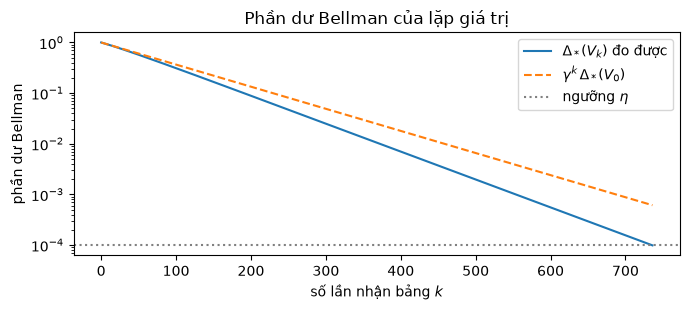

Delta_*(V_0) = 1 và mọi Delta_*(V_k) nằm dưới đường gamma^k * Delta_*(V_0).


In [29]:
ks = np.arange(len(deltas))
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.semilogy(ks, deltas, label=r"$\Delta_*(V_k)$ đo được")
ax.semilogy(ks, deltas[0] * GAMMA ** ks, "--", label=r"$\gamma^k\,\Delta_*(V_0)$")
ax.axhline(ETA, color="gray", linestyle=":", label=r"ngưỡng $\eta$")
ax.set_xlabel(r"số lần nhận bảng $k$")
ax.set_ylabel("phần dư Bellman")
ax.set_title("Phần dư Bellman của lặp giá trị")
ax.legend()
plt.tight_layout()
plt.show()
assert math.isclose(deltas[0], 1.0)
assert np.all(deltas <= deltas[0] * GAMMA ** ks + 1e-12)
print("Delta_*(V_0) = 1 và mọi Delta_*(V_k) nằm dưới đường gamma^k * Delta_*(V_0).")

### 7.4. Số lượt quét theo $\gamma$

Giữ $\varepsilon=0{,}01$ và đổi $\gamma$; mỗi giá trị $\gamma$ cho một MDP khác với giá trị tối ưu khác. Từ $\gamma^k\Delta_*(V_0)\le(1-\gamma)\varepsilon$ và $\Delta_*(V_0)=1$, số lượt quét đủ dùng là

$$k\ge\frac{\ln\big((1-\gamma)\varepsilon\big)}{\ln\gamma}.$$

In [30]:
print(" gamma   1/(1-gamma)   k đo được   k từ chặn gamma^k")
for g in [0.9, 0.95, 0.99, 0.995]:
    *_, k_g, lab, _ = value_iteration(P, R, g, (1 - g) * EPS, K=20_000)
    k_bound = math.ceil(math.log((1 - g) * EPS) / math.log(g))
    print(f"{g:6.3f}   {1 / (1 - g):11.0f}   {k_g:9d}   {k_bound:17d}   ({lab})")

 gamma   1/(1-gamma)   k đo được   k từ chặn gamma^k
 0.900            10          65                  66   (đạt ngưỡng)
 0.950            20         143                 149   (đạt ngưỡng)


 0.990           100         736                 917   (đạt ngưỡng)


 0.995           200        1315                1976   (đạt ngưỡng)


### 7.5. So sánh với lặp chính sách

Hai thuật toán giải cùng một MDP hữu hạn. Cần phân biệt hai đại lượng: sai số của bảng $\lVert V-v_*\rVert_\infty$, đã bị chặn bởi $\varepsilon$, và sai số của chính sách trích $\lVert v_{\pi_V}-v_*\rVert_\infty$. Chặn của Singh và Yee (1994) cho chính sách tham lam theo $V$ là

$$\lVert v_{\pi_V}-v_*\rVert_\infty\le\frac{2\gamma}{1-\gamma}\,\lVert V-v_*\rVert_\infty.$$

Ở đây có $v_*$ từ lặp chính sách và $v_{\pi_V}$ tính chính xác bằng hệ tuyến tính, nên cả hai sai số được đo trực tiếp và đặt cạnh chặn.

In [31]:
diff_cells = np.flatnonzero(pi_vi != pi_pi)
err_V = np.abs(V_vi - v_star).max()
v_pi_vi = evaluate_policy_exact(pi_vi, P, R, GAMMA)
print(f"||V_VI - v_*||_inf          = {err_V:.2e}  (chặn từ phần dư: {delta_vi / (1 - GAMMA):.2e})")
print(f"||v_(pi_V) - v_*||_inf      = {np.abs(v_pi_vi - v_star).max():.2e}  "
      f"(chặn Singh–Yee: {2 * GAMMA * err_V / (1 - GAMMA):.2e})")
print(f"Số ô mà pi_V khác chính sách của lặp chính sách: {len(diff_cells)}")
Q_star = lookahead(v_star, P, R, GAMMA)          # Q_*(s, a), cỡ (n, 2)
gap = np.abs(Q_star[:, 0] - Q_star[:, 1])         # khoảng cách giữa hai hành động tại từng ô
print(f"min_s |Q_*(s,0) - Q_*(s,1)| = {gap.min():.2e};  ngưỡng 2*gamma*||V - v_*|| = {2 * GAMMA * err_V:.2e}")
print(f"Số ô có khoảng cách không vượt ngưỡng (phép trích có thể chọn khác pi_*): {int((gap <= 2 * GAMMA * err_V).sum())}")
if len(diff_cells):
    print("   |Q_*(s,0) - Q_*(s,1)| tại các ô khác nhau:", gap[diff_cells].round(6))

||V_VI - v_*||_inf          = 7.84e-03  (chặn từ phần dư: 9.88e-03)
||v_(pi_V) - v_*||_inf      = 0.00e+00  (chặn Singh–Yee: 1.55e+00)
Số ô mà pi_V khác chính sách của lặp chính sách: 0
min_s |Q_*(s,0) - Q_*(s,1)| = 7.49e-04;  ngưỡng 2*gamma*||V - v_*|| = 1.55e-02
Số ô có khoảng cách không vượt ngưỡng (phép trích có thể chọn khác pi_*): 3


Vì $\lvert Q_V(s,a)-Q_*(s,a)\rvert\le\gamma\lVert V-v_*\rVert_\infty$ với mọi $(s,a)$, tại ô có $\lvert Q_*(s,0)-Q_*(s,1)\rvert>2\gamma\lVert V-v_*\rVert_\infty$ thứ tự của hai hành động theo $Q_V$ trùng thứ tự theo $Q_*$, nên $\pi_V(s)$ chắc chắn là hành động tối ưu. Tại ô có khoảng cách không vượt ngưỡng này, phép trích có thể chọn khác $\pi_*$ nhưng không bắt buộc. Output trên cho số ô dưới ngưỡng; nếu số đó dương mà hai chính sách vẫn trùng nhau ở mọi ô, kết quả minh họa đúng chữ "có thể".

### 7.6. Hình ảnh chính sách

Hình dưới vẽ chính sách của lặp chính sách trên lưới $(b_\theta,b_{\dot\theta})$ khi $x$ và $\dot x$ ở khoảng giữa ($b_x=b_{\dot x}=1$). `pi_pi.reshape(3, 3, 6, 6)[1, 1]` lấy đúng $36$ ô đó, cỡ $(6,6)$, hàng theo $b_\theta$ và cột theo $b_{\dot\theta}$. Mỗi ô ghi chữ T (đẩy trái) hoặc P (đẩy phải), nên hình đọc được cả khi không phân biệt màu.

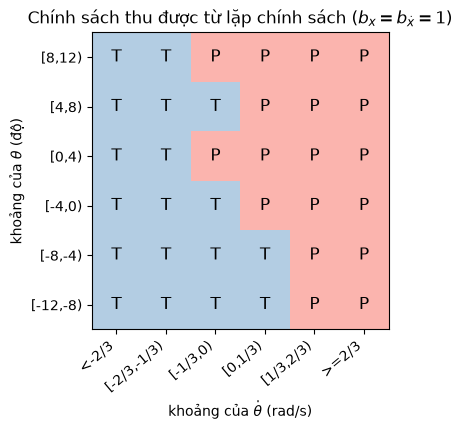

Số ô trong lưới khác pi0 (luật theo dấu góc): 14 / 36
Ô 170 (1, 1, 4, 2): Q_*(s,0) - Q_*(s,1) = 7.49e-04
Trị tuyệt đối của Q_*(s,0) - Q_*(s,1) trên lưới: trung vị 5.7799, lớn nhất 46.0815


In [32]:
grid = pi_pi.reshape(n_bins(CUTS))[1, 1]  # (3,3,6,6) -> chọn b_x = b_xdot = 1 -> (6 khoảng theta, 6 khoảng theta_dot)
theta_edges = np.degrees(np.r_[-THETA_MAX, CUTS[2], THETA_MAX])
fig, ax = plt.subplots(figsize=(5.4, 4.4))
cmap = matplotlib.colors.ListedColormap(["#b3cde3", "#fbb4ae"])  # màu nhạt để chữ T/P dễ đọc
ax.imshow(grid, cmap=cmap, vmin=0, vmax=1, origin="lower")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, "P" if grid[i, j] else "T", ha="center", va="center", fontsize=12)
ax.set_xticks(range(6), ["<-2/3", "[-2/3,-1/3)", "[-1/3,0)", "[0,1/3)", "[1/3,2/3)", ">=2/3"], rotation=40, ha="right")
ax.set_yticks(range(6), [f"[{theta_edges[i]:.0f},{theta_edges[i + 1]:.0f})" for i in range(6)])
ax.set_xlabel(r"khoảng của $\dot\theta$ (rad/s)")
ax.set_ylabel(r"khoảng của $\theta$ (độ)")
ax.set_title(r"Chính sách thu được từ lặp chính sách ($b_x=b_{\dot x}=1$)")
plt.tight_layout()
plt.show()
print("Số ô trong lưới khác pi0 (luật theo dấu góc):", int((grid != pi0.reshape(n_bins(CUTS))[1, 1]).sum()), "/ 36")
Q_grid = lookahead(v_star, P, R, GAMMA)  # Q_*(s, a), cỡ (n, 2)
s_odd = discretize([0.0, 0.0, np.radians(6), -1 / 6], CUTS)  # ô theta in [4, 8) độ, theta_dot in [-1/3, 0)
gap_grid = (Q_grid[:, 0] - Q_grid[:, 1]).reshape(n_bins(CUTS))[1, 1]  # Q_*(s,0) - Q_*(s,1) trên lưới, cỡ (6, 6)
print(f"Ô {s_odd} {cell_label(s_odd, CUTS)}: Q_*(s,0) - Q_*(s,1) = {Q_grid[s_odd, 0] - Q_grid[s_odd, 1]:.2e}")
print(f"Trị tuyệt đối của Q_*(s,0) - Q_*(s,1) trên lưới: trung vị {np.median(np.abs(gap_grid)):.4f}, lớn nhất {np.abs(gap_grid).max():.4f}")

**Câu hỏi:** Đọc hình trên và so sánh với luật theo dấu góc $\pi_0$. Hành động của chính sách thu được phụ thuộc chủ yếu vào biến nào? Giải thích bằng cơ chế vật lý đã thấy ở phần 2.

<details><summary>Lời giải</summary>

Các nhận xét dưới ứng với hình và output thu được với phiên bản gói in ở phần 1.

Ở bốn cột ngoài ($\lvert\dot\theta\rvert\ge1/3$ rad/s), hành động không phụ thuộc $\theta$: T ở hai cột $\dot\theta<-1/3$, P ở hai cột $\dot\theta\ge1/3$. Chỉ ở hai cột giữa ($\lvert\dot\theta\rvert<1/3$) hành động mới thay đổi theo $\theta$, và ở đó phần lớn các ô theo dấu của $\theta$ như $\pi_0$. Vậy hành động phụ thuộc chủ yếu vào khoảng của $\dot\theta$, trong khi $\pi_0$ chỉ đọc $\theta$; số ô khác nhau in ngay dưới hình.

Cơ chế vật lý: ở bước 1 của lượt luôn đẩy phải trong phần 2, góc gần như không đổi ($\theta\approx-0{,}003$ rad) nhưng $\dot\theta$ đổi từ $-0{,}013$ thành $-0{,}307$ rad/s. Lực đẩy sang phải làm $\dot\theta$ giảm, và theo đối xứng, lực đẩy sang trái làm $\dot\theta$ tăng. Khi cột đang quay sang phải ($\dot\theta\ge1/3$), chính sách đẩy phải để hãm chuyển động quay; khi cột quay sang trái ($\dot\theta<-1/3$), chính sách đẩy trái. Độ nghiêng $\theta$ chỉ quyết định hành động khi cột gần như không quay. Luật $\pi_0$ đẩy theo phía nghiêng kể cả khi cột đang quay về phía ngược lại, nên có thể làm cột vượt qua phương thẳng đứng và lệch sang phía kia.

Ô $\theta\in[4^\circ;8^\circ)$, $\dot\theta\in[-1/3;0)$ chọn T trong khi hai ô kề trên và dưới cùng cột chọn P. Output dưới hình cho thấy tại ô này $Q_*(s,0)-Q_*(s,1)$ nhỏ hơn nhiều so với trung vị của trị tuyệt đối trên lưới: hai hành động gần đồng hạng, nên lựa chọn tại ô này nhạy với sai số ước lượng $\hat p$ và không phản ánh một quy luật vật lý.

</details>

## 8. Đánh giá trong môi trường liên tục

**Ứng dụng.** Chính sách bảng $\pi$ được dùng trong CartPole liên tục qua phép rời rạc hóa: ở mỗi bước, hành động là $\pi(\mathrm{discretize}(o_t))$ với $o_t$ là quan sát. Bốn chính sách được đánh giá trên cùng $100$ hạt giống đánh giá; tập hạt giống này khác hạt giống dùng để ước lượng mô hình. Ngoài $\bar G\pm$ SE của từng chính sách, mã in hiệu theo cặp $\bar d\pm1{,}96\,\mathrm{SE}(d)$ giữa lặp chính sách và hai chính sách tham chiếu.

Đánh giá 4 chính sách x 100 lượt trong 2.0 giây

ngẫu nhiên             N=100  trung bình=  22.5  sd=  11.5  SE=  1.1  min=   9  max=  61  cắt ngắn= 0.0%
theo dấu góc           N=100  trung bình=  43.6  sd=   9.6  SE=  1.0  min=  25  max=  68  cắt ngắn= 0.0%
lặp chính sách         N=100  trung bình= 343.4  sd=  92.4  SE=  9.2  min= 182  max= 500  cắt ngắn= 2.0%
lặp giá trị            N=100  trung bình= 343.4  sd=  92.4  SE=  9.2  min= 182  max= 500  cắt ngắn= 2.0%

Hiệu theo cặp (lặp chính sách - ngẫu nhiên): 320.9 ± 18.0
Hiệu theo cặp (lặp chính sách - theo dấu góc): 299.8 ± 18.0


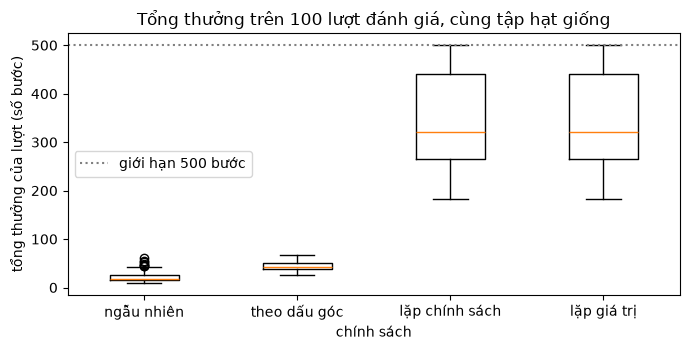

In [33]:
def tabular_policy(pi, cuts):
    # Chính sách liên tục: tra hành động của ô chứa quan sát
    return lambda obs, rng: int(pi[discretize(obs, cuts)])


policies = {
    "ngẫu nhiên": random_policy,
    "theo dấu góc": angle_policy,
    "lặp chính sách": tabular_policy(pi_pi, CUTS),
    "lặp giá trị": tabular_policy(pi_vi, CUTS),
}
t = time.perf_counter()
results = {name: evaluate(pol, N_EVAL) for name, pol in policies.items()}
print(f"Đánh giá {len(policies)} chính sách x {N_EVAL} lượt trong {time.perf_counter() - t:.1f} giây\n")
for name, res in results.items():
    summarize(name, res)
print()
for ref in ["ngẫu nhiên", "theo dấu góc"]:
    d, half = paired_difference(results["lặp chính sách"], results[ref])
    print(f"Hiệu theo cặp (lặp chính sách - {ref}): {d:.1f} ± {half:.1f}")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.boxplot([r["returns"] for r in results.values()])
ax.set_xticks(range(1, len(results) + 1), list(results.keys()))
ax.axhline(env.spec.max_episode_steps, color="gray", linestyle=":", label="giới hạn 500 bước")
ax.set_xlabel("chính sách")
ax.set_ylabel("tổng thưởng của lượt (số bước)")
ax.set_title(f"Tổng thưởng trên {N_EVAL} lượt đánh giá, cùng tập hạt giống")
ax.legend(loc="center left")
plt.tight_layout()
plt.show()

### 8.1. Giá trị dự đoán và tổng thưởng chiết khấu thực tế

Mô hình dự đoán giá trị $v_*(s)$ tại ô của trạng thái đầu. Tổng thưởng chiết khấu thực tế của một lượt dài $T$ bước là $G_0=(1-\gamma^T)/(1-\gamma)$ (câu hỏi ở phần 2). Đoạn mã dưới so sánh hai đại lượng trên cùng $100$ lượt của chính sách lặp chính sách, và in các đại lượng dùng để phân tích chênh lệch.

In [34]:
res = results["lặp chính sách"]
T_steps = res["returns"]
G_real = (1 - GAMMA ** T_steps) / (1 - GAMMA)                     # G_0 của từng lượt, cỡ (N,)
V_pred = np.array([v_star[discretize(s, CUTS)] for s in res["starts"]])
se_G = G_real.std(ddof=1) / math.sqrt(len(G_real))
print("Các ô chứa trạng thái đầu:", sorted({discretize(s, CUTS) for s in res["starts"]}))
print(f"Giá trị dự đoán trung bình v_*(ô đầu)              = {V_pred.mean():7.3f}")
print(f"Tổng thưởng chiết khấu thực tế trung bình         = {G_real.mean():7.3f}  (SE {se_G:.3f})")
print(f"Chênh lệch (thực tế - dự đoán)                    = {G_real.mean() - V_pred.mean():7.3f}")
print(f"Chặn sai số lặp: lặp chính sách ~ 0; lặp giá trị  = {delta_vi / (1 - GAMMA):7.3f}")
print(f"Mức giảm tối đa do cắt ngắn ở 500 bước            = {GAMMA ** 500 / (1 - GAMMA):7.3f}")
lo0, hi0 = cell_box(discretize(np.zeros(4), CUTS), CUTS, LIMITS)
print("Độ rộng ô chứa (0,0,0,0) theo từng biến          :", (hi0 - lo0).round(3), " (trạng thái đầu nằm trong ±0,05)")

Các ô chứa trạng thái đầu: [158, 159, 164, 165]
Giá trị dự đoán trung bình v_*(ô đầu)              =  84.473
Tổng thưởng chiết khấu thực tế trung bình         =  95.377  (SE 0.370)
Chênh lệch (thực tế - dự đoán)                    =  10.904
Chặn sai số lặp: lặp chính sách ~ 0; lặp giá trị  =   0.010
Mức giảm tối đa do cắt ngắn ở 500 bước            =   0.657
Độ rộng ô chứa (0,0,0,0) theo từng biến          : [1.6   1.    0.07  0.333]  (trạng thái đầu nằm trong ±0,05)


Chênh lệch giữa giá trị dự đoán và tổng thưởng chiết khấu thực tế đến từ các nguồn sau.

1. **Sai số lặp.** Lặp chính sách cho đúng $v_*$ của MDP hữu hạn, sai khác chỉ do làm tròn; lặp giá trị lệch tối đa $\varepsilon=0{,}01$. Khi chặn sai số lặp in ở trên nhỏ hơn nhiều so với chênh lệch đo được, nguồn này không giải thích được chênh lệch.
2. **Sai số thống kê.** Trung bình thực tế được ước lượng từ $100$ lượt, với SE in ở trên.
3. **Rời rạc hóa và ước lượng mô hình.** $v_*$ là giá trị trong MDP $(\hat p,\hat r)$: trạng thái trong ô được giả thiết phân bố đều, và ô kế tiếp được rút theo $\hat p$. Trong môi trường thật, trạng thái đầu nằm trong $[-0{,}05;\,0{,}05]^4$, một vùng nhỏ so với độ rộng của ô in ở trên, và chuỗi trạng thái liên tục đi theo động lực học tất định. Hai phân phối trạng thái khác nhau nên giá trị trung bình trên ô không bằng giá trị của các trạng thái thực sự gặp.
4. **Cắt ngắn.** Môi trường dừng ở $500$ bước nên $G_0\le(1-\gamma^{500})/(1-\gamma)$, trong khi mô hình không có giới hạn thời gian. Cắt ngắn chỉ làm giảm tổng thưởng chiết khấu thực tế, tối đa $\gamma^{500}/(1-\gamma)$ như in ở trên.

Phần dư Bellman nhỏ chỉ chứng nhận nguồn thứ nhất.

### 8.2. Trực quan hóa một lượt của bốn chính sách

Mục 3.1 đã ghi và vẽ một lượt của hai chính sách tham chiếu. Mục này dùng lại các hàm `record_episode`, `end_reason`, `plot_trajectories`, `draw_cartpole` và `cartpole_player` của mục 3.1 cho bốn chính sách, trên cùng hạt giống minh họa `VIZ_SEED`, nên lượt của hai chính sách tham chiếu trùng với mục 3.1 và cả bốn bắt đầu từ cùng trạng thái. Với chính sách bảng, `record_episode` nhận thêm `cell_fn` để ghi chỉ số ô $\mathrm{discretize}(s_t)$ của từng trạng thái.

Một lượt chỉ là một mẫu. Vì vậy ô dưới còn ghi lý do kết thúc của chính sách lặp chính sách trên cả $100$ lượt đánh giá ở đầu phần 8.

In [35]:
cell_of = lambda s: discretize(s, CUTS)       # ánh xạ trạng thái -> chỉ số ô
viz_env = make_env()
episodes = {name: record_episode(viz_env, pol, VIZ_SEED, cell_of) for name, pol in policies.items()}
viz_env.close()
for name, ep in episodes.items():
    assert len(ep["actions"]) == results[name]["returns"][i_viz]   # trùng lượt tương ứng trong phép đánh giá
print(f"Hạt giống minh họa: {VIZ_SEED} (lượt thứ {i_viz} của phép đánh giá, như mục 3.1)")
describe_episodes(episodes, geom)
for name in ["lặp chính sách", "lặp giá trị"]:
    print(f"{name}: số ô đã đi qua = {len(set(episodes[name]['cells']))}")
pi_grid = pi_pi.reshape(n_bins(CUTS))                          # (3, 3, 6, 6): trục đầu là b_x
depends_on_bx = pi_grid.max(axis=0) != pi_grid.min(axis=0)     # (3, 6, 6): hành động đổi theo b_x
print(f"Tỉ lệ tổ hợp (b_xdot, b_theta, b_thetadot) mà hành động của lặp chính sách đổi theo b_x: "
      f"{depends_on_bx.mean():.1%} ({depends_on_bx.sum()}/{depends_on_bx.size})")

# Lý do kết thúc của lặp chính sách trên cả 100 lượt đánh giá
eval_env = make_env()
reasons = [end_reason(record_episode(eval_env, policies["lặp chính sách"], int(sd)), geom)
           for sd in results["lặp chính sách"]["seeds"]]
eval_env.close()
print(f"\nLặp chính sách, lý do kết thúc trên {len(reasons)} lượt đánh giá:",
      {r: reasons.count(r) for r in sorted(set(reasons))})

Hạt giống minh họa: 10004 (lượt thứ 4 của phép đánh giá, như mục 3.1)
ngẫu nhiên      T =  12 bước ( 0.24 giây), kết thúc do |θ| > 12 độ, |x| lớn nhất = 0.127, |theta| lớn nhất trước bước cuối = 10.9 độ
theo dấu góc    T =  42 bước ( 0.84 giây), kết thúc do |θ| > 12 độ, |x| lớn nhất = 0.219, |theta| lớn nhất trước bước cuối = 11.6 độ
lặp chính sách  T = 448 bước ( 8.96 giây), kết thúc do |x| > 2.4, |x| lớn nhất = 2.404, |theta| lớn nhất trước bước cuối = 5.3 độ
lặp giá trị     T = 448 bước ( 8.96 giây), kết thúc do |x| > 2.4, |x| lớn nhất = 2.404, |theta| lớn nhất trước bước cuối = 5.3 độ
lặp chính sách: số ô đã đi qua = 31
lặp giá trị: số ô đã đi qua = 31
Tỉ lệ tổ hợp (b_xdot, b_theta, b_thetadot) mà hành động của lặp chính sách đổi theo b_x: 13.9% (15/108)



Lặp chính sách, lý do kết thúc trên 100 lượt đánh giá: {'cắt ngắn ở 500 bước': 2, '|x| > 2.4': 98}


**Đồ thị theo thời gian.** Chính sách lặp giá trị trùng chính sách lặp chính sách ở mọi ô (mục 7.5), nên hai đường của chúng trùng nhau; đường lặp giá trị vẽ nét đứt đè lên nét liền.

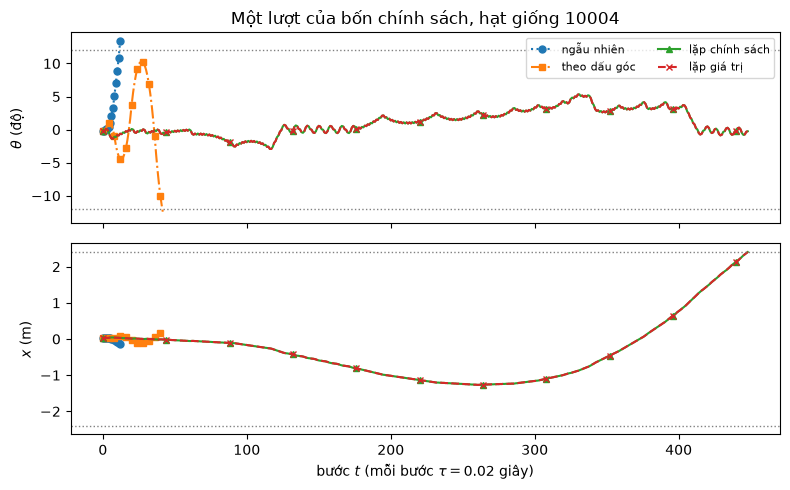

In [36]:
plot_trajectories(episodes, geom, STYLES, f"Một lượt của bốn chính sách, hạt giống {VIZ_SEED}")

**Hoạt hình.** Trình phát của mục 3.1 hiển thị bốn ô, mỗi ô rộng $400$ px; trên màn hình hẹp các ô tự xuống dòng. Mọi bước đều được phát, ở tốc độ chọn trong ô tốc độ so với thời gian thực. Khi xem, đối chiếu mũi tên với hình chính sách ở mục 7.6: với chính sách lặp chính sách, hướng lực đổi theo dấu của $\dot\theta$ nhiều hơn theo dấu của $\theta$.

In [37]:
display(HTML(cartpole_player(episodes, geom)))

Trình phát: 4 lượt, dài nhất 448 bước; HTML nhúng 24 kB


**Dải ảnh tĩnh.** Sáu thời điểm cách đều trong lượt của chính sách lặp chính sách (đọc từ trái sang phải, từ trên xuống), vẽ bằng cùng hàm `draw_cartpole`; mỗi ảnh ghi bước, thời gian và hành động tại bước đó. Dải ảnh hiển thị được cả khi JavaScript không chạy.

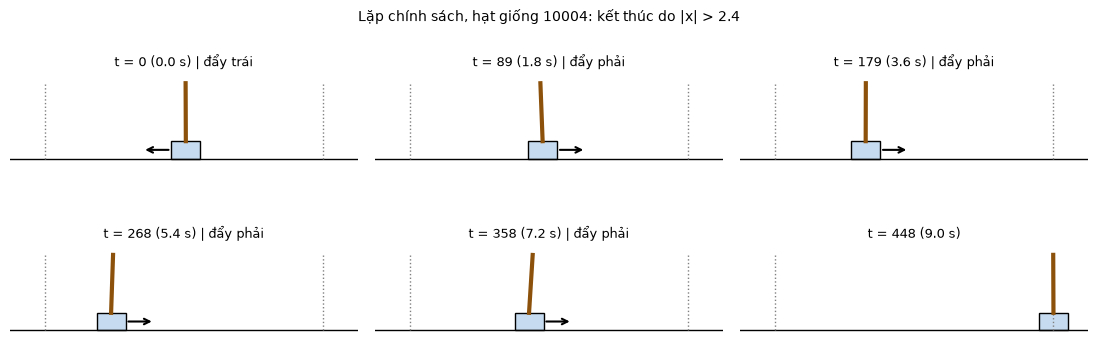

In [38]:
def filmstrip(ep, geom, n, title):
    T = len(ep["actions"])
    ts = np.linspace(0, T, n).astype(int)                         # n thời điểm cách đều, gồm 0 và T
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(11, 3.6))
    for ax, k in zip(axes.ravel(), ts):
        action = ep["actions"][k] if k < T else None
        label = "" if action is None else (" | đẩy phải" if action == 1 else " | đẩy trái")
        draw_cartpole(ax, ep["states"][k], action, geom, title=f"t = {k} ({k * geom['tau']:.1f} s){label}")
    fig.suptitle(title, fontsize=10)
    fig.subplots_adjust(left=0.01, right=0.99, bottom=0.02, top=0.85, wspace=0.05, hspace=0.35)
    plt.show()


ep_pi = episodes["lặp chính sách"]
filmstrip(ep_pi, geom, 6, f"Lặp chính sách, hạt giống {VIZ_SEED}: kết thúc do {end_reason(ep_pi, geom)}")

Kết luận về chất lượng của chính sách dựa trên đánh giá $100$ lượt ở đầu phần 8; dòng cuối của output đầu mục 8.2 ghi lý do kết thúc trên cả $100$ lượt đó. Lượt ghi lại cho biết lượt dừng vì góc hay vì vị trí, và trạng thái thực sự đi qua những ô nào; đó là phân phối trạng thái mà nguồn sai lệch thứ ba ở mục 8.1 nhắc tới.

**Câu hỏi:** Dựa vào output và đồ thị trên, lượt của chính sách lặp chính sách kết thúc vì biến nào? Liên hệ kết quả đó với các biến mà chính sách thực sự điều khiển theo hình ở mục 7.6.

<details><summary>Lời giải</summary>

Với phiên bản gói in ở phần 1, output cho thấy lượt minh họa của lặp chính sách kết thúc do $\lvert x\rvert>2{,}4$, trong khi $\lvert\theta\rvert$ lớn nhất trước bước cuối còn cách xa ngưỡng $12^\circ$. Đồ thị $x(t)$ cho thấy xe lệch sang trái hơn một mét, rồi chạy sang phải và vượt ngưỡng $2{,}4$, trong khi $\theta(t)$ chỉ dao động trong vài độ quanh $0$. Dòng thống kê trên $100$ lượt đánh giá cho thấy hiện tượng này không riêng lượt minh họa: mọi lượt không bị cắt ngắn đều kết thúc vì $\lvert x\rvert>2{,}4$.

Hình ở mục 7.6 cho thấy hành động được chọn chủ yếu theo $\dot\theta$ và $\theta$. Hai yếu tố có thể giải thích việc xe trôi tới ngưỡng; cả hai là giả thuyết cần kiểm.

1. Mỗi khoảng của $x$ rộng $1{,}6$ m, nên mọi vị trí trong khoảng giữa $[-0{,}8;\,0{,}8)$ cho cùng hành động, và $\dot x$ cũng chỉ có ba khoảng. Chính sách vẫn phụ thuộc $b_x$ ở một phần các tổ hợp $(b_{\dot x},b_\theta,b_{\dot\theta})$; output in tỉ lệ các tổ hợp mà hành động đổi theo $b_x$.
2. Với $\gamma=0{,}99$, tầm nhìn hiệu dụng khoảng $100$ bước, ngắn hơn nhiều so với vài trăm bước mà xe cần để trôi tới ngưỡng. Trong MDP $(\hat p,\hat r)$, một hành động chỉ làm xe trôi chậm hơn thì có ảnh hưởng nhỏ lên giá trị chiết khấu.

Nhiệm vụ 1 (đổi cách chia $x$, $\dot x$) và nhiệm vụ 5 (đổi $\gamma$) ở phần 10 kiểm tra hai giả thuyết này.

</details>

### 8.3. Độ nhạy theo mẫu của mô hình

Mô hình $\hat p$ được ước lượng từ mẫu ngẫu nhiên, nên một hạt giống khác cho một mô hình khác và có thể cho một chính sách khác. Hàm `run_pipeline` gói toàn bộ chuỗi: ước lượng mô hình, lặp giá trị tới ngưỡng, đánh giá trên cùng $100$ lượt. Đoạn mã dưới chạy chuỗi này với năm hạt giống mô hình, rồi báo trung bình và độ lệch chuẩn của $\bar G$ theo hạt giống mô hình.

In [39]:
def run_pipeline(cuts, limits, n_samples, model_seed, gamma=GAMMA, eps=EPS, n_eval=N_EVAL, env_kwargs=None):
    # Ước lượng (P, R) -> lặp giá trị tới ngưỡng -> đánh giá trong môi trường liên tục
    P_m, R_m = build_tabular_mdp(cuts, limits, n_samples, model_seed, env_kwargs)
    V_m, pi_m, delta_m, k_m, label_m, _ = value_iteration(P_m, R_m, gamma, (1 - gamma) * eps, K=20_000)
    res_m = evaluate(tabular_policy(pi_m, cuts), n_eval)
    return {"P": P_m, "R": R_m, "V": V_m, "pi": pi_m, "k": k_m, "label": label_m, "res": res_m}


t = time.perf_counter()
means = []
print("hạt giống mô hình   số ô khác pi_V (SEED)   trung bình tổng thưởng    SE")
for model_seed in range(SEED, SEED + 5):
    if model_seed == SEED:
        pi_m, g = pi_vi, results["lặp giá trị"]["returns"]   # dùng lại kết quả đã có
    else:
        out = run_pipeline(CUTS, LIMITS, M, model_seed)
        pi_m, g = out["pi"], out["res"]["returns"]
    means.append(g.mean())
    print(f"{model_seed:17d}   {int((pi_m != pi_vi).sum()):21d}   {g.mean():22.1f}   {g.std(ddof=1) / math.sqrt(len(g)):4.1f}")
means = np.array(means)
print(f"\nTrung bình theo {len(means)} hạt giống mô hình: {means.mean():.1f}; độ lệch chuẩn giữa các hạt giống: {means.std(ddof=1):.1f}")
print(f"({time.perf_counter() - t:.1f} giây)")

hạt giống mô hình   số ô khác pi_V (SEED)   trung bình tổng thưởng    SE
             2026                       0                    343.4    9.2


             2027                      24                    221.3    3.7


             2028                      18                    219.2    3.4


             2029                      26                    500.0    0.0


             2030                      17                    220.2    3.7

Trung bình theo 5 hạt giống mô hình: 300.8; độ lệch chuẩn giữa các hạt giống: 123.5
(18.0 giây)


Mỗi dòng là chính sách trích từ lặp giá trị đạt ngưỡng trên mô hình của dòng đó, nên khác biệt giữa các dòng đến từ mô hình ước lượng. Khi độ lệch chuẩn giữa các hạt giống mô hình lớn hơn nhiều so với SE của từng dòng, kết quả của một lần ước lượng mô hình chưa đủ để kết luận về một cách rời rạc hóa; cần báo cáo trung bình theo nhiều hạt giống mô hình như dòng cuối.

**Câu hỏi:** Có đề xuất giảm sai số yêu cầu xuống $\varepsilon=10^{-8}$ để cải thiện tổng thưởng trong môi trường thật. Dựa vào các nguồn sai lệch ở trên và kết quả mục 7.5, đánh giá đề xuất này.

<details><summary>Lời giải</summary>

Giảm $\varepsilon$ chỉ giảm sai số lặp: với $\varepsilon=0{,}01$, $\lVert V-v_*\rVert_\infty\le0{,}01$ trên thang giá trị cỡ $100$. Chính sách trích chỉ có thể đổi tại các ô mà hai hành động gần đồng hạng. Mục 7.5 đã so $\pi_V$ với chính sách của lặp chính sách, tức chính sách ứng với $\varepsilon\to0$; nếu hai chính sách trùng nhau ở mọi ô thì giảm $\varepsilon$ không đổi chính sách nào, trong khi số lượt quét tăng theo $\ln(1/\varepsilon)/\ln(1/\gamma)$. Mục 8.3 cho thấy đổi mẫu của mô hình có thể làm tổng thưởng thay đổi nhiều; để cải thiện trong môi trường thật cần tác động vào cách rời rạc hóa, số mẫu $M$ hoặc cách lấy mẫu khi ước lượng mô hình.

</details>

## 9. Tổng kết

- CartPole được đưa về MDP hữu hạn gồm $324$ ô và một trạng thái kết thúc. Mô hình $\hat p(s'\mid s,a)=N(s,a,s')/M$ được ước lượng bằng $M=200$ bước mô phỏng cho mỗi cặp ô–hành động; $\hat r(s,a)=1$.
- Đánh giá chính sách được tính chính xác bằng hệ $(I-\gamma P_\pi)V=r_\pi$ và bằng lặp có ngưỡng; sai số thật luôn nằm dưới chặn $\Delta_\pi(V)/(1-\gamma)$.
- Lặp chính sách với quy tắc giữ hòa dừng ở một chính sách ổn định thỏa $T_*v=v$. Lặp giá trị với $\eta=(1-\gamma)\varepsilon$ cho bảng lệch $v_*$ không quá $\varepsilon$, và phần dư giảm dưới đường $\gamma^k$.
- Các bảo đảm trên thuộc về MDP hữu hạn đã ước lượng. Kết quả trong CartPole liên tục còn chịu sai số rời rạc hóa, sai số ước lượng mô hình và giới hạn $500$ bước; mục 8.3 đo một phần sai số này qua độ nhạy theo hạt giống mô hình.

In [40]:
print(f"Tổng thời gian chạy notebook tới đây: {time.perf_counter() - T0:.1f} giây")

Tổng thời gian chạy notebook tới đây: 29.3 giây


## 10. Gợi mở tìm hiểu và cải tiến

**Quy trình làm lại.** Mọi hàm từ phần 4 trở đi nhận cách chia (`cuts`, `limits`), mô hình (`P`, `R`) và $\gamma$ làm tham số, và lấy kích thước từ `P.shape`. Để thử một thay đổi:

1. đổi cách chia: tạo `cuts` và `limits` mới (không cần sửa `CUTS`, `LIMITS`); đổi mô hình: đổi `n_samples`, `model_seed` hoặc `env_kwargs`; đổi bài toán: đổi `gamma` hoặc `eps`;
2. gọi `run_pipeline(cuts, limits, n_samples, model_seed, gamma, eps)`; hàm này chạy lại phần 5 (ước lượng mô hình), mục 7.2 (lặp giá trị) và phần 8 (đánh giá) cho cấu hình mới;
3. muốn dùng lặp chính sách, đánh giá lặp hoặc các phép kiểm khác thì gọi các hàm của phần 6–7 với `out["P"]`, `out["R"]`. Chính sách khởi tạo phải có đúng cỡ mới $n$ = `out["P"].shape[1]`, ví dụ `np.zeros(n, dtype=int)` hoặc luật theo dấu góc trên cách chia mới `np.array([int(cell_label(s, cuts)[2] >= len(cuts[2]) // 2 + 1) for s in range(n)])` (đúng khi điểm cắt giữa của $\theta$ bằng $0$ và số điểm cắt lẻ); đánh giá chính sách thu được trong môi trường thật bằng `evaluate(tabular_policy(pi, cuts))`;
4. so sánh với cấu hình gốc bằng `summarize` và `paired_difference`, và lặp lại với vài hạt giống mô hình như mục 8.3.

Ví dụ dưới bỏ hẳn $x$ và $\dot x$ (mỗi biến một khoảng), giữ nguyên cách chia $\theta$ và $\dot\theta$, nên chỉ còn $36$ ô.

In [41]:
cuts_small = [np.array([]), np.array([]), CUTS[2], CUTS[3]]   # 1 x 1 x 6 x 6 = 36 ô
t = time.perf_counter()
out_small = run_pipeline(cuts_small, LIMITS, M, SEED)
print(f"Số ô: {out_small['P'].shape[1]}; lặp giá trị: k = {out_small['k']}, nhãn '{out_small['label']}' "
      f"({time.perf_counter() - t:.1f} giây)")
summarize("1x1x6x6, lặp giá trị", out_small["res"])
summarize("3x3x6x6, lặp giá trị", results["lặp giá trị"])
d, half = paired_difference(out_small["res"], results["lặp giá trị"])
print(f"Hiệu theo cặp (1x1x6x6 - 3x3x6x6): {d:.1f} ± {half:.1f}  (một hạt giống mô hình)")

Số ô: 36; lặp giá trị: k = 701, nhãn 'đạt ngưỡng' (1.8 giây)
1x1x6x6, lặp giá trị   N=100  trung bình= 500.0  sd=   0.0  SE=  0.0  min= 500  max= 500  cắt ngắn=100.0%
3x3x6x6, lặp giá trị   N=100  trung bình= 343.4  sd=  92.4  SE=  9.2  min= 182  max= 500  cắt ngắn= 2.0%
Hiệu theo cặp (1x1x6x6 - 3x3x6x6): 156.6 ± 18.1  (một hạt giống mô hình)


Kết quả trên chỉ dùng một hạt giống mô hình, nên chưa cho biết biến thiên theo mô hình như mục 8.3. Khi mọi lượt đều chạm giới hạn $500$ bước, phép đo không phân biệt thêm được các chính sách đạt mức đó. Cách chia $1\times1\times6\times6$ không quan sát $x$ và $\dot x$, nên chính sách không kiểm soát vị trí xe; trong một lượt dài hơn $500$ bước, xe có thể trôi tới ngưỡng $\lvert x\rvert>2{,}4$. Ví dụ này không đủ để kết luận cách chia nào tốt hơn; nhiệm vụ 1 kiểm tra điều đó với giới hạn số bước lớn hơn và nhiều hạt giống mô hình.

**Nhiệm vụ.** Các nhiệm vụ độc lập với nhau. Với mỗi nhiệm vụ, giữ cố định mọi thứ khác, báo cáo trung bình và SE trên cùng tập hạt giống đánh giá, và khi có thể, lặp lại với vài hạt giống mô hình như mục 8.3.

1. **Số khoảng và điểm cắt.** Thử $1\times3\times6\times6$, $3\times3\times8\times8$ và $3\times3\times12\times12$, và lặp lại ví dụ $1\times1\times6\times6$ ở trên với nhiều hạt giống mô hình. Đo số ô, thời gian ước lượng mô hình, số lượt quét của lặp giá trị và tổng thưởng trong môi trường thật. Đối chiếu với hạn chế bùng nổ số trạng thái khi tăng số khoảng ở tr. 37 của bài giảng. Khi mọi lượt của hai cấu hình đều đạt $500$ bước, phép đánh giá chạm trần và không phân biệt được hai cấu hình; khi đó đánh giá thêm với giới hạn dài hơn, ví dụ `evaluate(pol, env_kwargs={"max_episode_steps": 2000})`, và theo dõi $\lvert x\rvert$ cuối lượt.
2. **Điểm cắt theo phân vị.** Thay các khoảng đều bằng điểm cắt tại phân vị của dữ liệu quan sát, ví dụ `np.percentile(obs[:, j], np.linspace(0, 100, m + 1)[1:-1])` cho $m$ khoảng, với dữ liệu thu từ chính sách ngẫu nhiên hoặc từ chính sách của lặp chính sách. So sánh số quan sát mỗi ô và tổng thưởng.
3. **Số mẫu $M$.** Chạy $M\in\{25,50,100,200,400\}$, mỗi giá trị với $3$ hạt giống mô hình. Vẽ trung bình tổng thưởng và độ lệch giữa các hạt giống theo $M$.
4. **Mô hình từ quỹ đạo.** Thay lấy mẫu đều trong ô bằng các chuyển $(s,a,s')$ thu khi chạy một chính sách thăm dò (ví dụ chọn ngẫu nhiên với xác suất $0{,}3$, còn lại theo $\pi$ hiện tại). Ước lượng $\hat p(s'\mid s,a)=N(s,a,s')/N(s,a)$ bằng tần suất. Cặp $(s,a)$ có $N(s,a)=0$ cần một quy ước nêu rõ, ví dụ coi cặp đó chuyển tới $s_{\mathrm{term}}$ (giá trị bi quan); so sánh với mô hình lấy mẫu đều. Khung hàm `collect_transitions` và `model_from_transitions` ở dưới.
5. **Hệ số chiết khấu.** Lặp lại phần 6–8 với $\gamma\in\{0{,}9;\,0{,}95;\,0{,}995\}$. Ghi số lượt quét, số ô mà chính sách đổi so với $\gamma=0{,}99$, và tổng thưởng thực tế.
6. **Lặp giá trị tại chỗ.** Dùng `value_iteration_in_place` ở dưới (lịch tại chỗ của Bài 04) với thứ tự $s=0,\dots,n-1$ và với một thứ tự khác. Đếm số lượt quét cần để phần dư đạt $\eta$, so với lặp đồng bộ.
7. **Lặp chính sách cải biên.** Thay đánh giá chính xác bằng $m$ lần áp dụng $T_\pi$ bắt đầu từ bảng của vòng trước, với $m\in\{1,5,20\}$. Đo số vòng và tổng số phép áp dụng toán tử. Bảo đảm dừng hữu hạn của Bài 04 chỉ áp dụng cho đánh giá chính xác.
8. **Đo mức phân tán do gộp ô và kiểm tra tính Markov.** (a) Vẽ histogram entropy của $\hat p(\cdot\mid s,a)$ cho mọi cặp, rồi lặp lại sau khi làm mịn điểm cắt của $\dot\theta$; kiểm tra câu trả lời ở câu hỏi cuối phần 5. (b) Kiểm tra tính Markov trực tiếp: từ quỹ đạo, ước lượng $\hat p(s'\mid s,a,s_{\text{trước}})$ theo ô trước đó và so với $\hat p(s'\mid s,a)$ bằng khoảng cách biến phân toàn phần $\mathrm{TV}=\tfrac12\sum_{s'}\lvert\hat p(s'\mid s,a,s_{\text{trước}})-\hat p(s'\mid s,a)\rvert$. Với dữ liệu hữu hạn, TV dương cả khi quá trình có tính Markov; để có mốc so sánh, tính lại TV sau khi hoán vị ngẫu nhiên nhãn $s_{\text{trước}}$ giữa các chuyển có cùng $(s,a)$. Khung hàm `markov_tv` ở dưới.
9. **Phần thưởng khác.** Dùng `env_kwargs={"sutton_barto_reward": True}` (thưởng $0$ ở bước thường, $-1$ ở bước kết thúc) khi gọi `build_tabular_mdp` hoặc `run_pipeline`; $\hat r$ được tính lại từ phần thưởng của bộ mô phỏng. Phép kiểm `R == 1` ở phần 5 và các công thức tính tay $V_1=1$ ở mục 6.1, 7.1 chỉ đúng cho thưởng mặc định nên phải bỏ hoặc sửa. Đánh giá trong môi trường thật vẫn đo bằng số bước. So sánh chính sách thu được với chính sách ở phần 6.
10. **Môi trường khác.** Áp dụng cùng quy trình cho `MountainCar-v0` hoặc `Acrobot-v1`. Lấy số chiều trạng thái từ `env.observation_space.shape[0]` và số hành động từ `env.action_space.n` thay cho số $4$ trong `cell_box`, `build_tabular_mdp` và hằng `N_ACTIONS = 2`. Xác định ngưỡng kết thúc, biên lấy mẫu và cách gán `state` cho từng môi trường bằng cách đọc mã nguồn Gymnasium tương ứng; với `Acrobot-v1`, quan sát (cos, sin của góc) khác biến trạng thái bên trong.
11. **Liên hệ Bài 05: dự đoán không cần mô hình.** Ước lượng $v_\pi$ của chính sách cuối bằng Monte Carlo hoặc sai phân thời gian TD(0) trên cùng phép rời rạc hóa, từ các lượt tương tác, rồi so với `evaluate_policy_exact(pi, P, R, GAMMA)`. Giá trị Monte Carlo trên môi trường thật và $v_\pi$ của MDP $(\hat p,\hat r)$ là hai đại lượng khác nhau (phần 8).
12. **Trực quan hóa ô rời rạc.** Vẽ `episodes[name]["cells"]` theo thời gian, hoặc bốn chỉ số khoảng `cell_label(c, CUTS)` với `c` lấy từ `episodes[name]["cells"]`, chồng lên $\theta(t)$ và $x(t)$ ở mục 8.2, để thấy lượt đi qua bao nhiêu ô và đổi ô ở những thời điểm nào. Nếu muốn hình chuẩn của Gymnasium, cài `gymnasium[classic-control]` (kéo theo pygame), tạo môi trường với `render_mode="rgb_array"` và hiển thị mảng ảnh của `env.render()` bằng `plt.imshow`.
13. **Liên hệ Bài 06: điều khiển không cần mô hình.** Giữ nguyên `discretize` nhưng bỏ mô hình: học bảng $Q$ bằng Q-learning từ các lượt tương tác. So sánh số bước môi trường cần dùng và tổng thưởng đạt được với quy trình ước lượng mô hình rồi lập kế hoạch ở notebook này.

Các khung hàm dưới chỉ định nghĩa hàm; lời gọi mẫu được đặt trong chú thích.

In [42]:
# ---- Nhiệm vụ 4 và 8(b): thu chuyển từ quỹ đạo
def collect_transitions(policy, n_episodes, seed, cuts):
    # Trả danh sách (s_trước, s, a, s_kế): s_trước = -1 ở bước đầu, s_kế = n (s_term) khi kết thúc.
    # Bước bị cắt ngắn không phải kết thúc nên s_kế là ô của quan sát cuối.
    n = int(np.prod(n_bins(cuts)))
    env = make_env()
    data = []
    for i in range(n_episodes):
        rng = np.random.default_rng(seed + i)
        obs, _ = env.reset(seed=seed + i)
        s_prev, s = -1, discretize(obs, cuts)
        while True:
            a = policy(obs, rng)
            obs, r, terminated, truncated, _ = env.step(a)
            s_next = n if terminated else discretize(obs, cuts)
            data.append((s_prev, s, a, s_next))
            if terminated or truncated:
                break
            s_prev, s = s, s_next
    env.close()
    return data


# ---- Nhiệm vụ 4: mô hình tần suất từ quỹ đạo
def model_from_transitions(data, cuts):
    n = int(np.prod(n_bins(cuts)))
    counts = np.zeros((N_ACTIONS, n, n + 1))
    for _, s, a, s_next in data:
        counts[a, s, s_next] += 1                  # N(s, a, s')
    n_sa = counts.sum(axis=2, keepdims=True)       # N(s, a), cỡ (|A|, n, 1)
    missing = n_sa[..., 0] == 0
    P_traj = np.divide(counts, n_sa, out=np.zeros_like(counts), where=n_sa > 0)
    P_traj[missing, n] = 1.0                       # quy ước: cặp chưa có dữ liệu chuyển tới s_term
    R_traj = np.ones((N_ACTIONS, n))               # thưởng mặc định +1 mỗi bước
    return P_traj, R_traj, missing


# ---- Nhiệm vụ 8(b): khoảng cách biến phân toàn phần giữa p(s'|s,a,s_trước) và p(s'|s,a)
def markov_tv(data, min_count=30):
    from collections import Counter, defaultdict
    by_sa, by_psa = defaultdict(Counter), defaultdict(Counter)
    for s_prev, s, a, s_next in data:
        by_sa[(s, a)][s_next] += 1
        if s_prev >= 0:
            by_psa[(s_prev, s, a)][s_next] += 1
    rows = []
    for (s_prev, s, a), cnt in by_psa.items():
        n_psa = sum(cnt.values())
        if n_psa < min_count:                      # bỏ nhóm quá ít dữ liệu
            continue
        base = by_sa[(s, a)]
        n_sa = sum(base.values())
        tv = 0.5 * sum(abs(cnt[x] / n_psa - base[x] / n_sa) for x in set(cnt) | set(base))
        rows.append((s_prev, s, a, n_psa, tv))
    return rows  # mốc so sánh: chạy lại sau khi hoán vị s_trước trong từng nhóm (s, a)


# ---- Nhiệm vụ 6: lặp giá trị tại chỗ, cùng quy ước K và nhãn với value_iteration
def value_iteration_in_place(P, R, gamma, eta, K, order=None):
    n = P.shape[1]
    order = np.arange(n) if order is None else order
    V_plus = np.zeros(n + 1)                       # V trên S+, V_plus[n] = V(s_term) = 0
    k = 0
    while True:
        V = V_plus[:n].copy()
        delta = np.abs(lookahead(V, P, R, gamma).max(axis=1) - V).max()  # Delta_*(V) đo đồng bộ
        if delta <= eta:
            return V, k, "đạt ngưỡng"
        if k == K:
            return V, k, "hết ngân sách, chưa đạt ngưỡng"
        for s in order:                            # ghi đè ngay: ô sau trong lượt quét đọc giá trị mới
            V_plus[s] = max(R[a, s] + gamma * P[a, s] @ V_plus for a in range(P.shape[0]))
        k += 1


# Ví dụ gọi (bỏ dấu # để chạy):
# Chính sách thăm dò của nhiệm vụ 4: ngẫu nhiên với xác suất 0,3, còn lại theo pi_pi
# (chính sách tất định thuần sẽ không thử hành động còn lại, nên nhiều cặp (s, a) thiếu dữ liệu)
# explore = lambda obs, rng: int(rng.integers(N_ACTIONS)) if rng.random() < 0.3 else int(pi_pi[discretize(obs, CUTS)])
# data = collect_transitions(explore, 50, SEED, CUTS)
# P_traj, R_traj, missing = model_from_transitions(data, CUTS); print(missing.sum(), "cặp (s, a) thiếu dữ liệu")
# rows = markov_tv(data); print(len(rows), "nhóm; TV trung vị", np.median([r[-1] for r in rows]))
# V_ip, k_ip, label_ip = value_iteration_in_place(P, R, GAMMA, ETA, 5_000); print(k_ip, label_ip)

**Tài liệu tham khảo**

- Tạ Việt Cường, *Bài 04: Giải MDP*, Học tăng cường, học kỳ 2 năm học 2025–2026, tr. 35–37 (CartPole và rời rạc hóa).
- R. S. Sutton, A. G. Barto, *Reinforcement Learning: An Introduction*, ấn bản 2, MIT Press, 2018, §4.1–4.4, tr. 74–84 (đánh giá chính sách, cải thiện chính sách, lặp chính sách, lặp giá trị).
- S. P. Singh, R. C. Yee, An upper bound on the loss from approximate optimal-value functions, *Machine Learning* 16 (1994), 227–233 (chặn sai số của chính sách tham lam ở mục 7.5).
- Gymnasium, tài liệu môi trường CartPole: https://gymnasium.farama.org/environments/classic_control/cart_pole/